###### Jason Mrad 202400809 | Jean Abi Khalil 202302369 | Jean Paul Hatem 202400360 | Isabelle Nigolian 202302736

# Medical Insurance Risk Classification Model

### Step-1- Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
)

import time
import warnings
from sklearn.exceptions import UndefinedMetricWarning

import joblib

### Step-2- Load DataSet

In [2]:
# ---------------------------
# CONFIG
# ---------------------------
DATA_PATH = '../data/medical_insurance.csv'
SHOW_PLOTS = True
RANDOM_STATE = 42
TARGET_SOURCE = 'risk_score'
RISK_LABEL_NAME = 'risk_label'
RISK_BINS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]    # Low / Medium / High
RISK_BIN_LABELS = ['Very Low', 'Low', 'Medium', 'High','Very High']
CORR_THRESHOLD = 0.05    # minimum correlation with target to keep feature
F_SCORE_THRESHOLD = 0.05 # minimum SelectKBest f_score to keep feature
target = 'risk_label'

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 110})

# ---------------------------
# LOAD DATA
# ---------------------------
df = pd.read_csv(DATA_PATH)
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")

# ---------------------------
# Candidate features
# ---------------------------
candidate_features = [
    "cancer_history", "kidney_disease", "liver_disease", "arthritis", "mental_health",
    "proc_imaging_count", "proc_surgery_count", "proc_physio_count", "proc_consult_count", "proc_lab_count",
    "is_high_risk", "had_major_procedure",
    "hospitalizations_last_3yrs", "days_hospitalized_last_3yrs", "medication_count",
    "systolic_bp", "diastolic_bp", "ldl", "hba1c",
    "plan_type", "network_tier", "deductible", "copay", "policy_term_years", "policy_changes_last_2yrs",
    "annual_premium", "monthly_premium", "premium_ratio", "monthly_premium_ratio",
    "provider_quality",
    "claims_count", "avg_claim_amount", "total_claims_paid",
    "chronic_count", "hypertension", "diabetes", "asthma", "copd", "cardiovascular_disease",
    "age", "income", "household_size", "dependents", "bmi", "visits_last_year",
    "sex", "region", "urban_rural", "education", "marital_status", "employment_status",
    "smoker", "alcohol_freq"
]
candidate_features = [c for c in candidate_features if c in df.columns]
print(f"Candidate features present in data: {len(candidate_features)}\n")

Data loaded: 99990 rows, 54 columns

Candidate features present in data: 51



### Step-3- Data Preprocessing

In [3]:
# ---------------------------
# Missing value handling (alcohol_freq)
# ---------------------------
if 'alcohol_freq' in df.columns:
    df['alcohol_freq'] = df['alcohol_freq'].fillna('Never')


In [4]:
# ---------------------------
# Encoding helpers
# ---------------------------
def _is_binary_like(series):
    vals = series.dropna().unique()
    if len(vals) != 2:
        return False
    if pd.api.types.is_bool_dtype(series):
        return True
    lower = [str(v).strip().lower() for v in vals]
    binary_tokens = set(['yes','no','y','n','true','false','t','f','male','female','m','f','1','0'])
    return any(tok in binary_tokens for tok in lower)

def meaningful_binary_map(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in {'yes','y','true','t','1','male','m','high','risk','positive'}:
        return 1
    if s in {'no','n','false','f','0','female','fem','low','healthy','negative'}:
        return 0
    if s.isdigit():
        return int(s)
    return 1 if s >= 'm' else 0

def smart_encode_column(series):
    uniq = series.dropna().unique()
    n_unique = len(uniq)
    if n_unique == 0:
        return pd.DataFrame({series.name: []})
    if n_unique == 2 or _is_binary_like(series):
        return series.map(meaningful_binary_map).to_frame()
    if n_unique <= 6:
        try:
            sorted_vals = sorted(uniq, key=lambda x: (str(x).lower()))
        except Exception:
            sorted_vals = list(uniq)
        mapping = {val: idx for idx, val in enumerate(sorted_vals)}
        return series.map(mapping).to_frame()
    if n_unique <= 15:
        return pd.get_dummies(series, prefix=series.name, drop_first=False)
    codes, uniques = pd.factorize(series)
    return pd.DataFrame({series.name: codes})


def plot_classification_features(df_local, features, t=RISK_LABEL_NAME, show=SHOW_PLOTS, ncols=2, figsize=(14,10), top_n_categories=10):
    if not show or len(features) == 0:
        return
    n = len(features)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(features):
        ax = axes[i]
        try:
            ser = df_local[col]
            if np.issubdtype(ser.dtype, np.number):
                if ser.nunique() <= 1:
                    ax.text(0.5, 0.5, f"Feature '{col}' has low variance", ha='center', va='center', fontsize=12)
                    ax.set_axis_off()
                elif ser.nunique() <= 6:
                    sns.countplot(x=col, hue=t, data=df_local, ax=ax, palette="Set2")
                    ax.set_ylabel("Count")
                    ax.set_xlabel(col.replace('_', ' ').title())
                else:
                    sns.boxplot(x=t, y=col, data=df_local, ax=ax, palette="Set2", showfliers=True)
                    ax.set_ylabel(col.replace('_', ' ').title())
                    ax.set_xlabel(target.replace('_', ' ').title())
            else:
                counts = ser.value_counts().nlargest(top_n_categories)
                if len(counts) == 0:
                    ax.text(0.5, 0.5, f"No data for '{col}'", ha='center', va='center', fontsize=12)
                    ax.set_axis_off()
                else:
                    top_ser = ser.where(ser.isin(counts.index))
                    sns.countplot(x=top_ser, hue=df_local[t], ax=ax, palette="Set2")
                    ax.set_ylabel("Count")
                    ax.set_xlabel(col.replace('_', ' ').title())
                    ax.set_title(f"{col.replace('_',' ').title()} vs {target.replace('_',' ').title()}", fontsize=11)
                    ax.tick_params(axis='x', rotation=15)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error plotting {col}\n{e}", ha='center', va='center', fontsize=12)
            ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


In [5]:
# ---------------------------
# Create categorical risk target
# ---------------------------
if TARGET_SOURCE in df.columns and pd.api.types.is_numeric_dtype(df[TARGET_SOURCE]):
    rs = df[TARGET_SOURCE].astype(float).clip(lower=0)
    df[RISK_LABEL_NAME] = pd.cut(rs, bins=RISK_BINS, labels=RISK_BIN_LABELS, include_lowest=True)
    print(f"Created '{RISK_LABEL_NAME}' from '{TARGET_SOURCE}'.")
else:
    raise RuntimeError(f"No numeric source for risk label. Provide '{TARGET_SOURCE}'.")

print("\nClass distribution:")
print(df[RISK_LABEL_NAME].value_counts(dropna=False))

Created 'risk_label' from 'risk_score'.

Class distribution:
risk_label
Medium       28178
Low          24523
High         20829
Very High    15944
Very Low     10516
Name: count, dtype: int64



Encoding complete. Encoded columns: 52


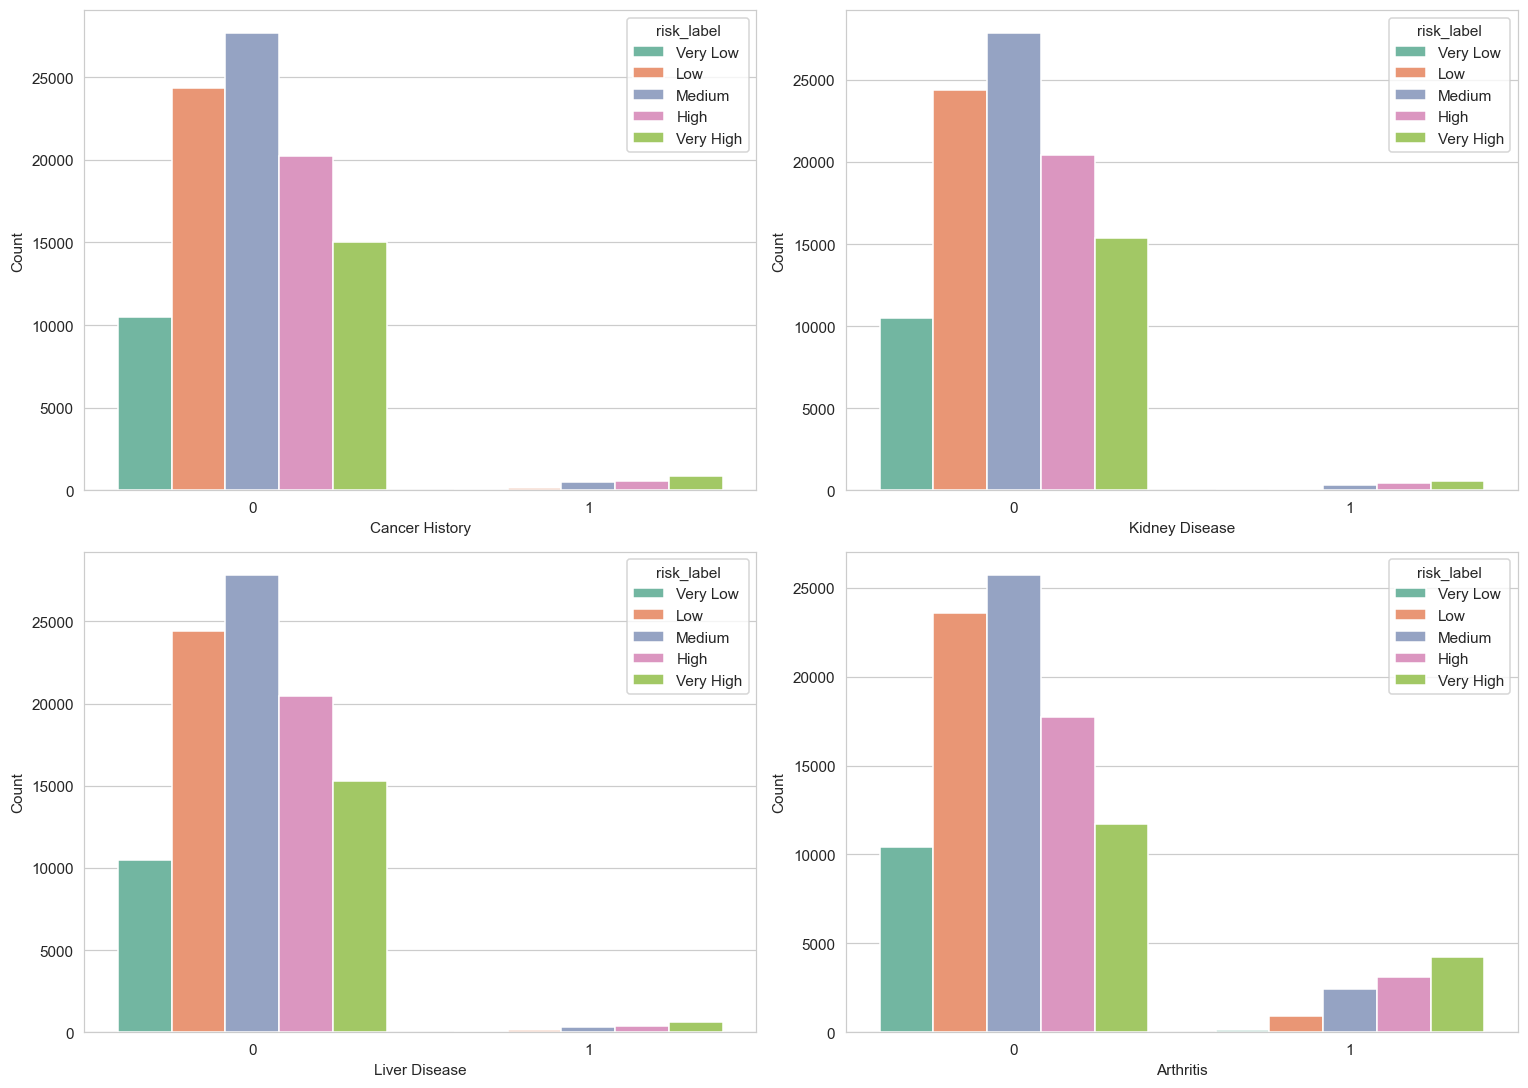

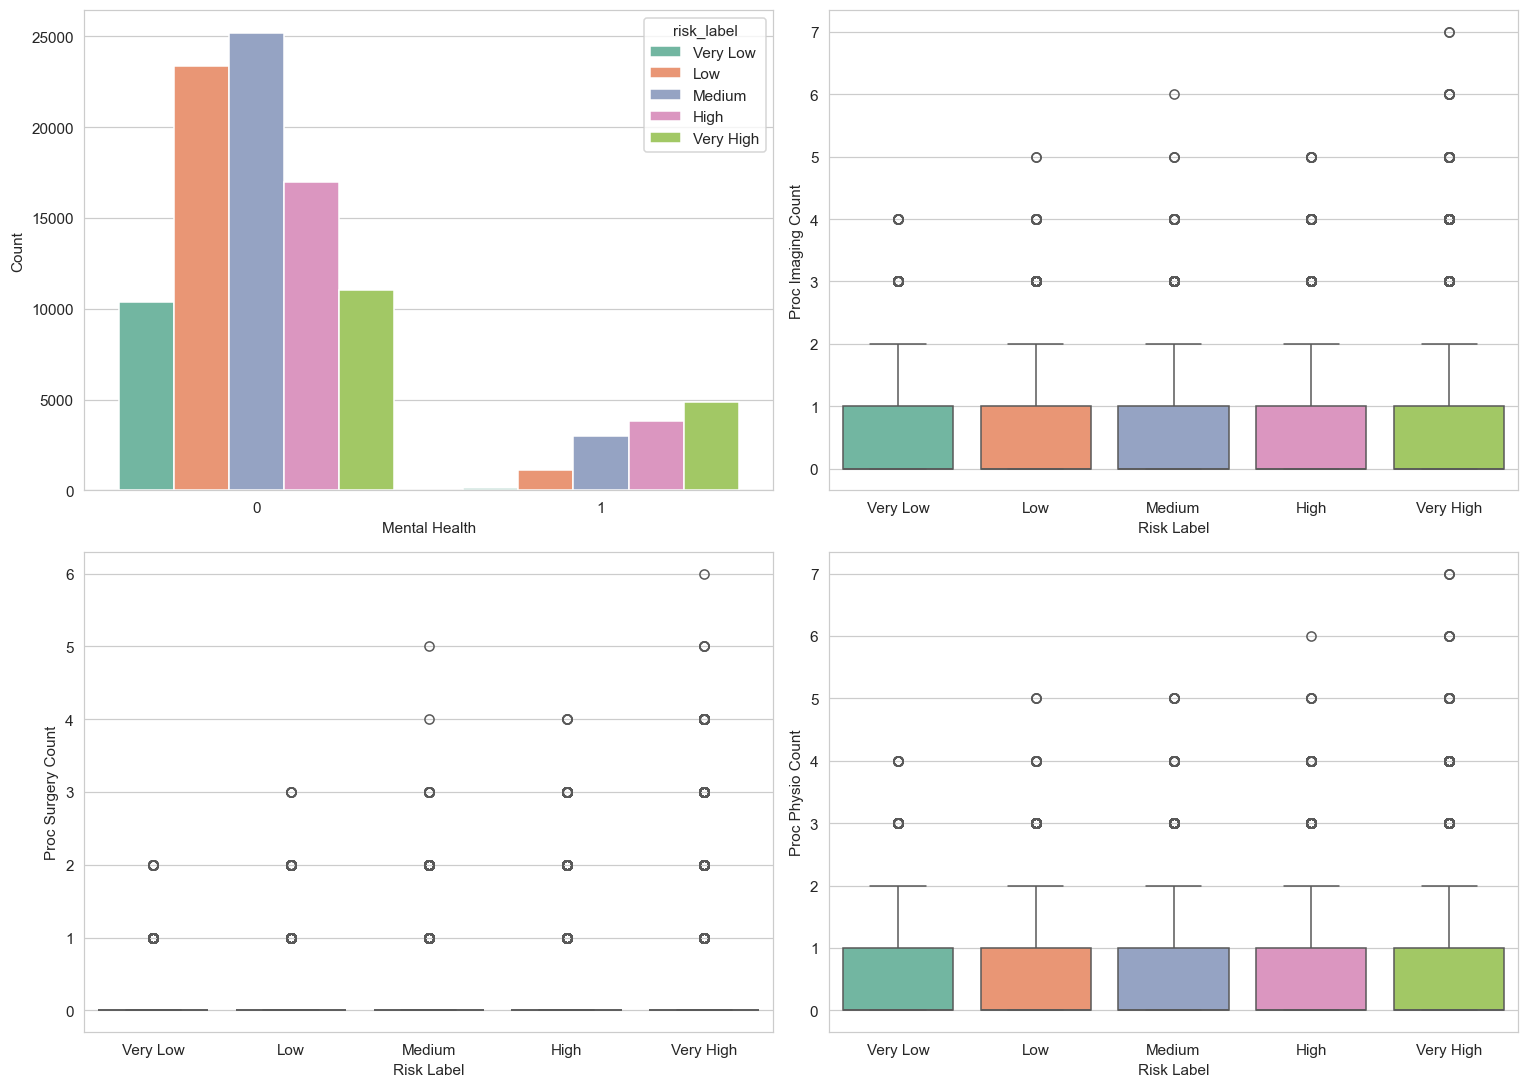

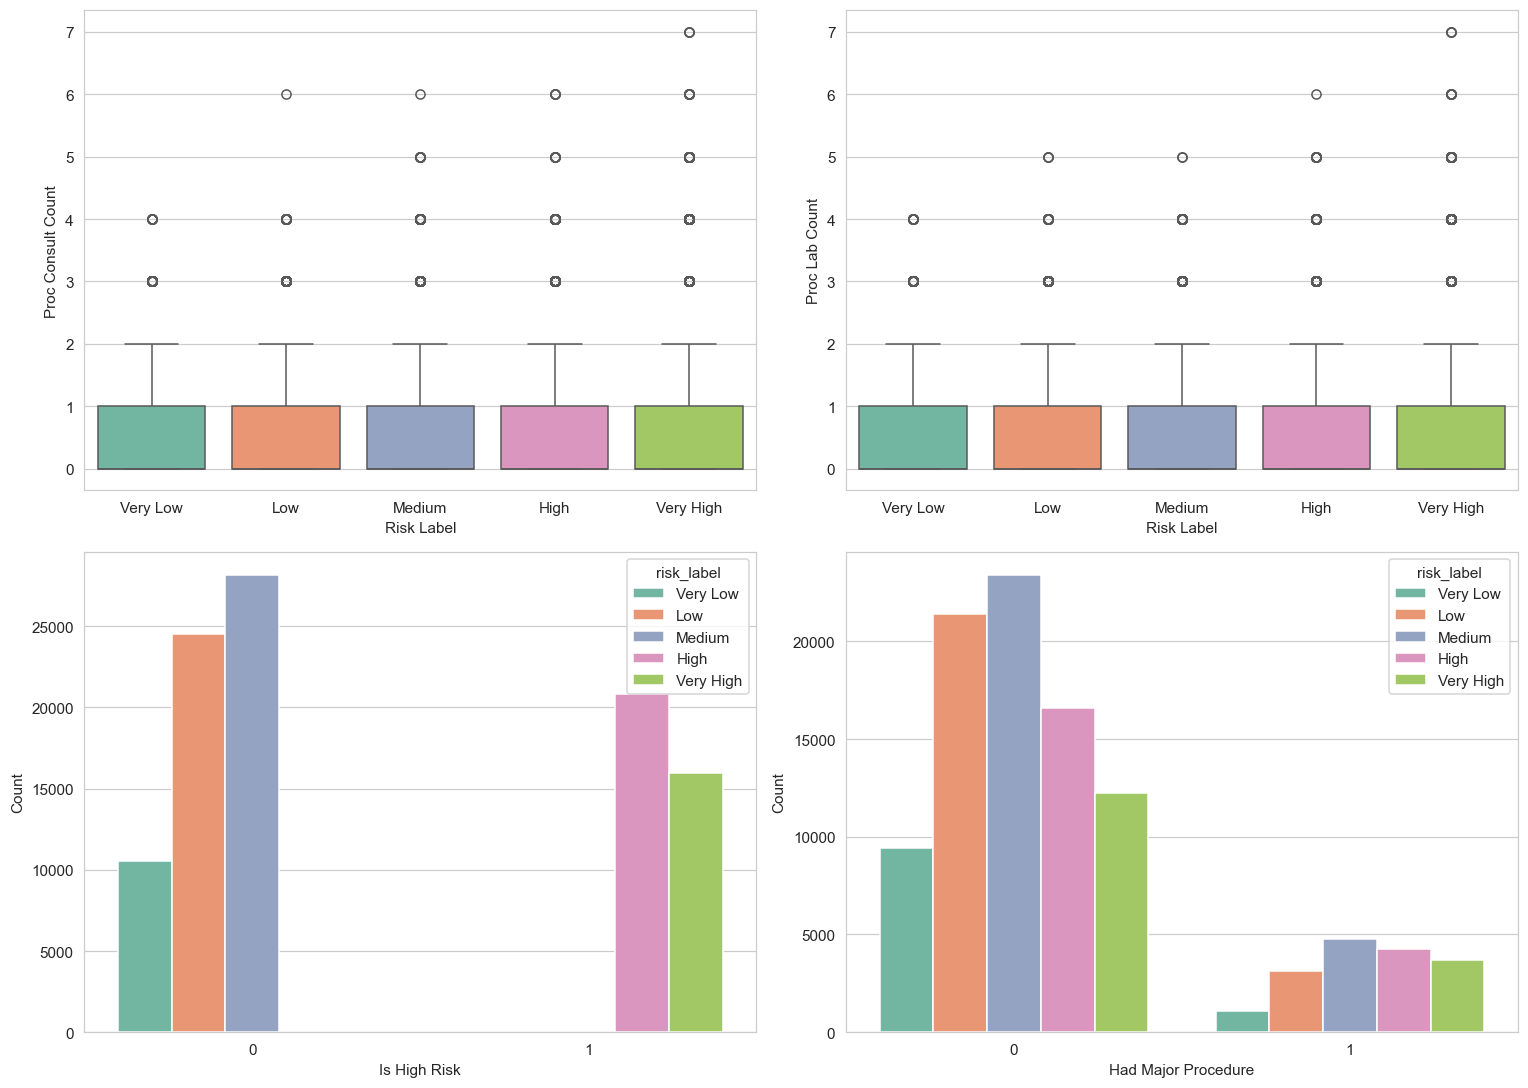

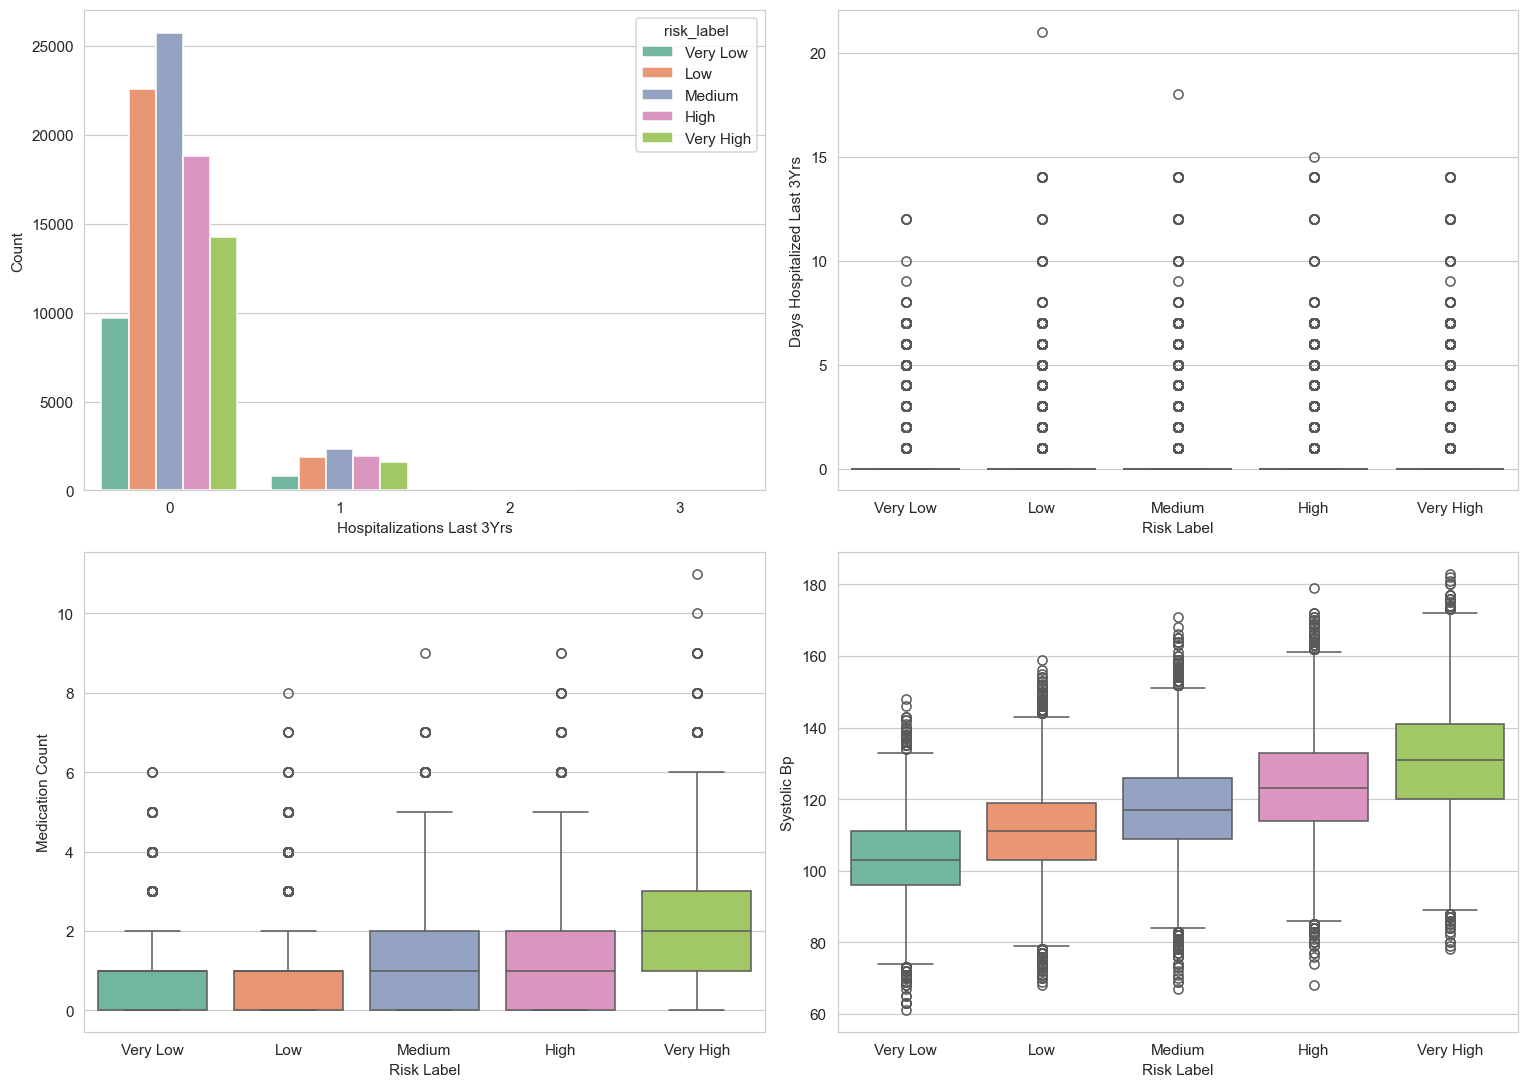

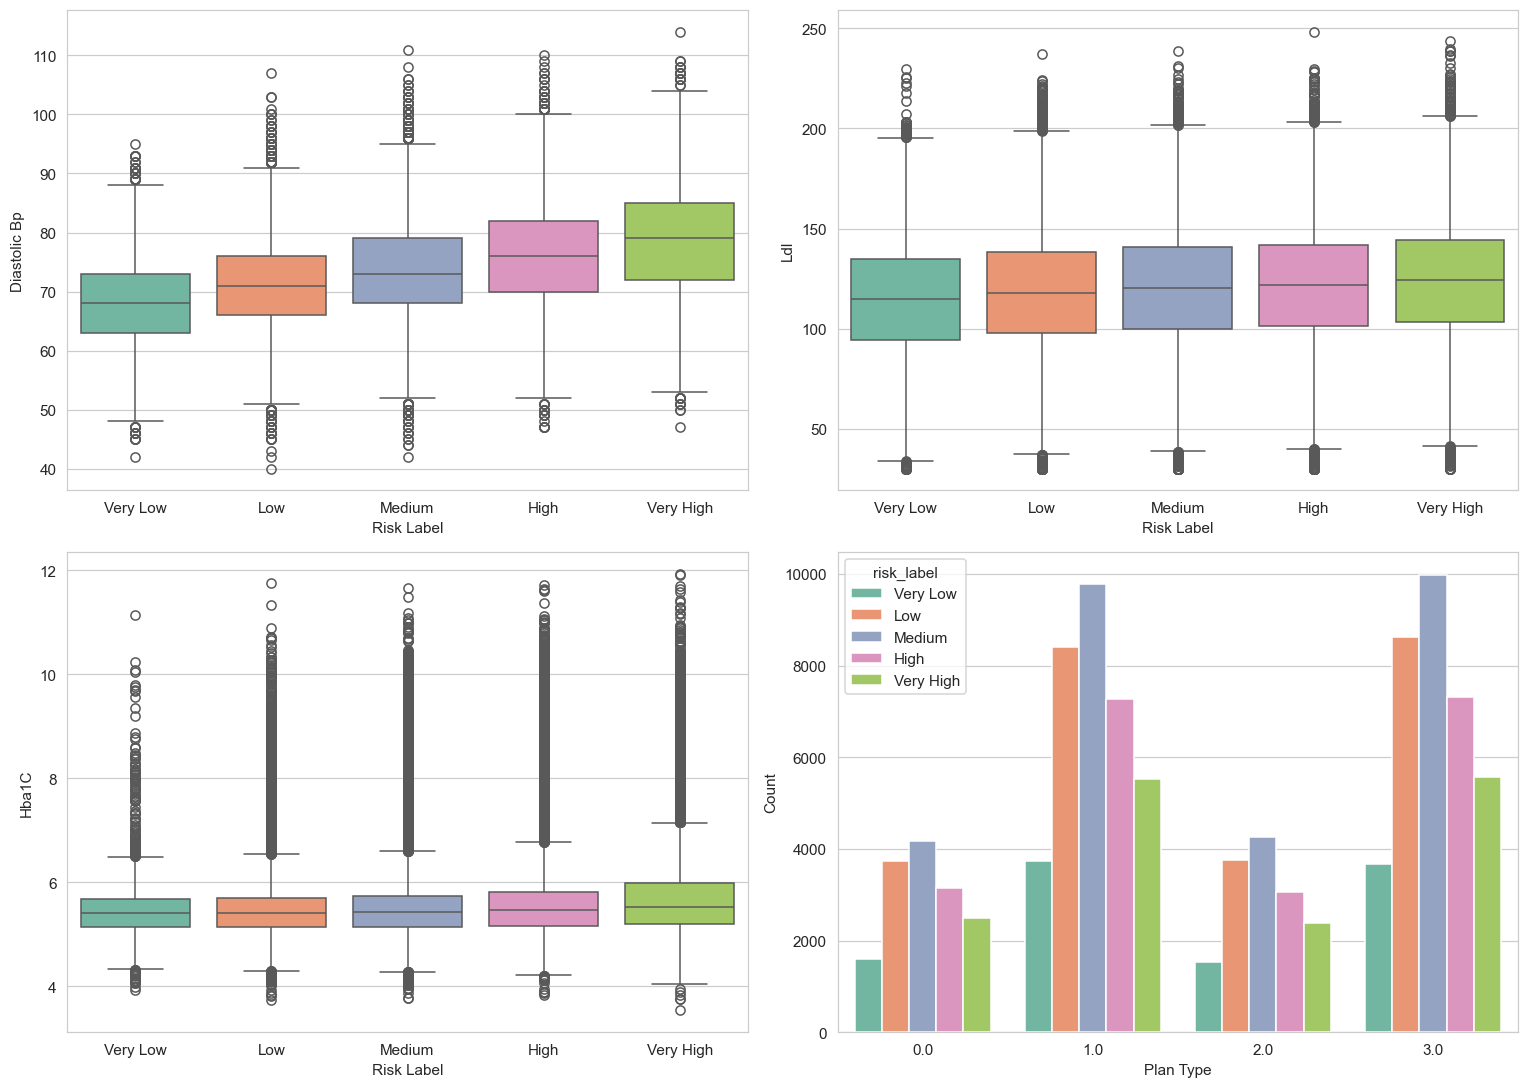

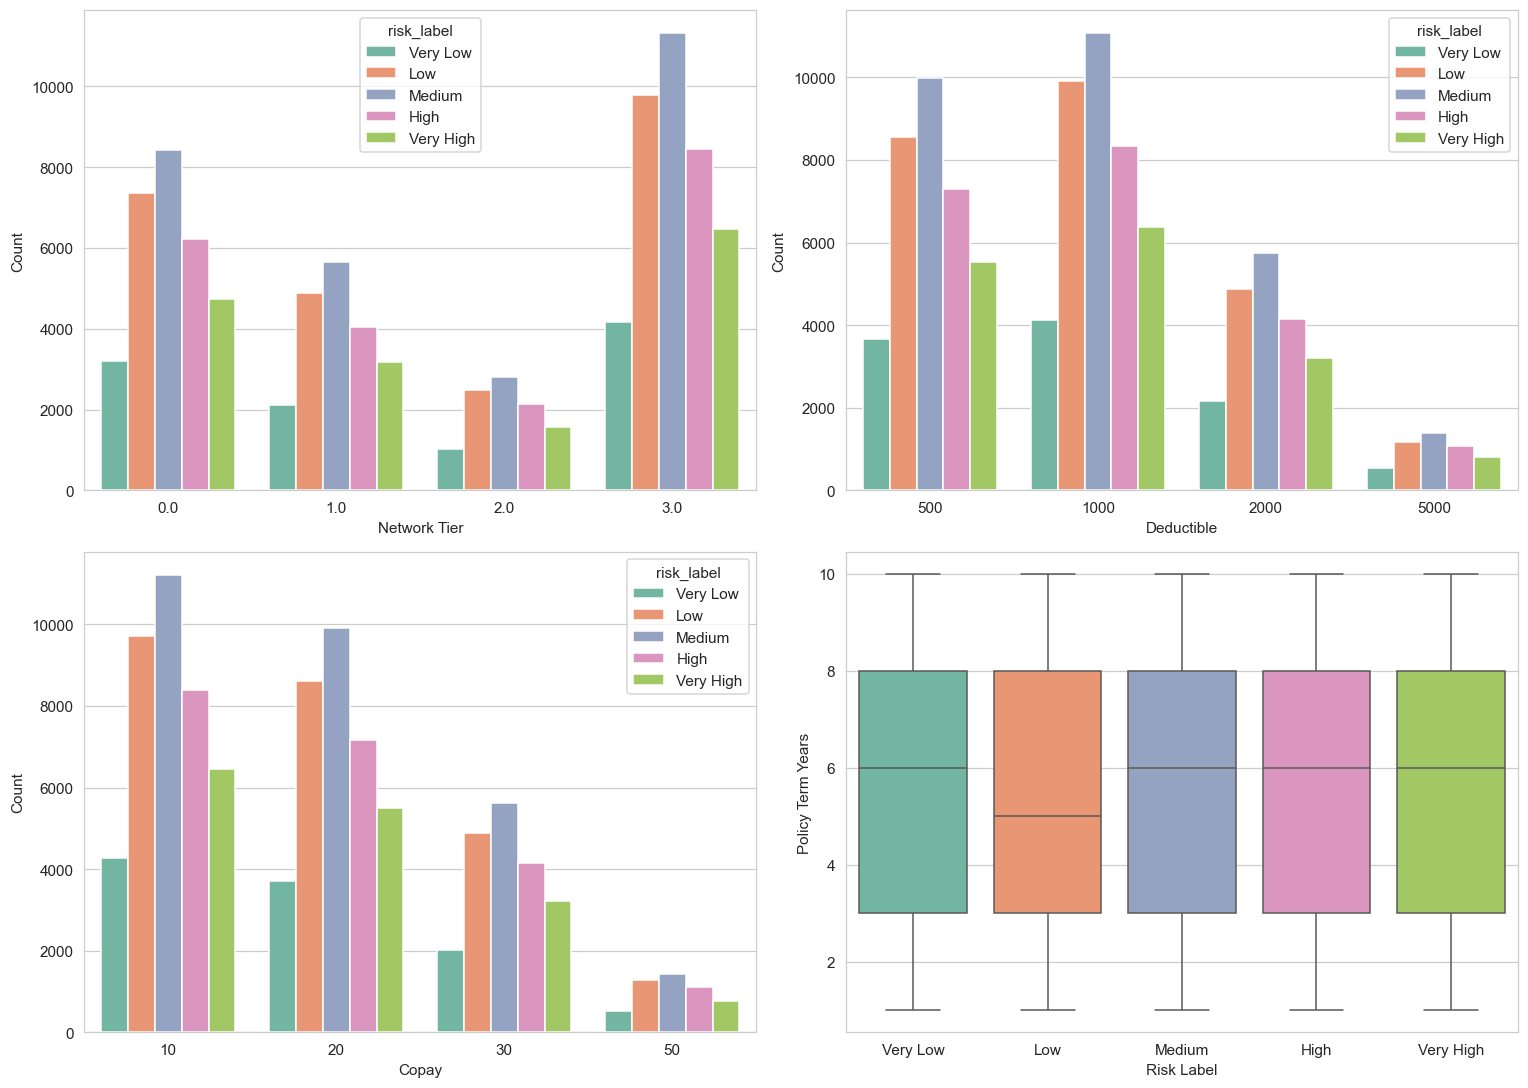

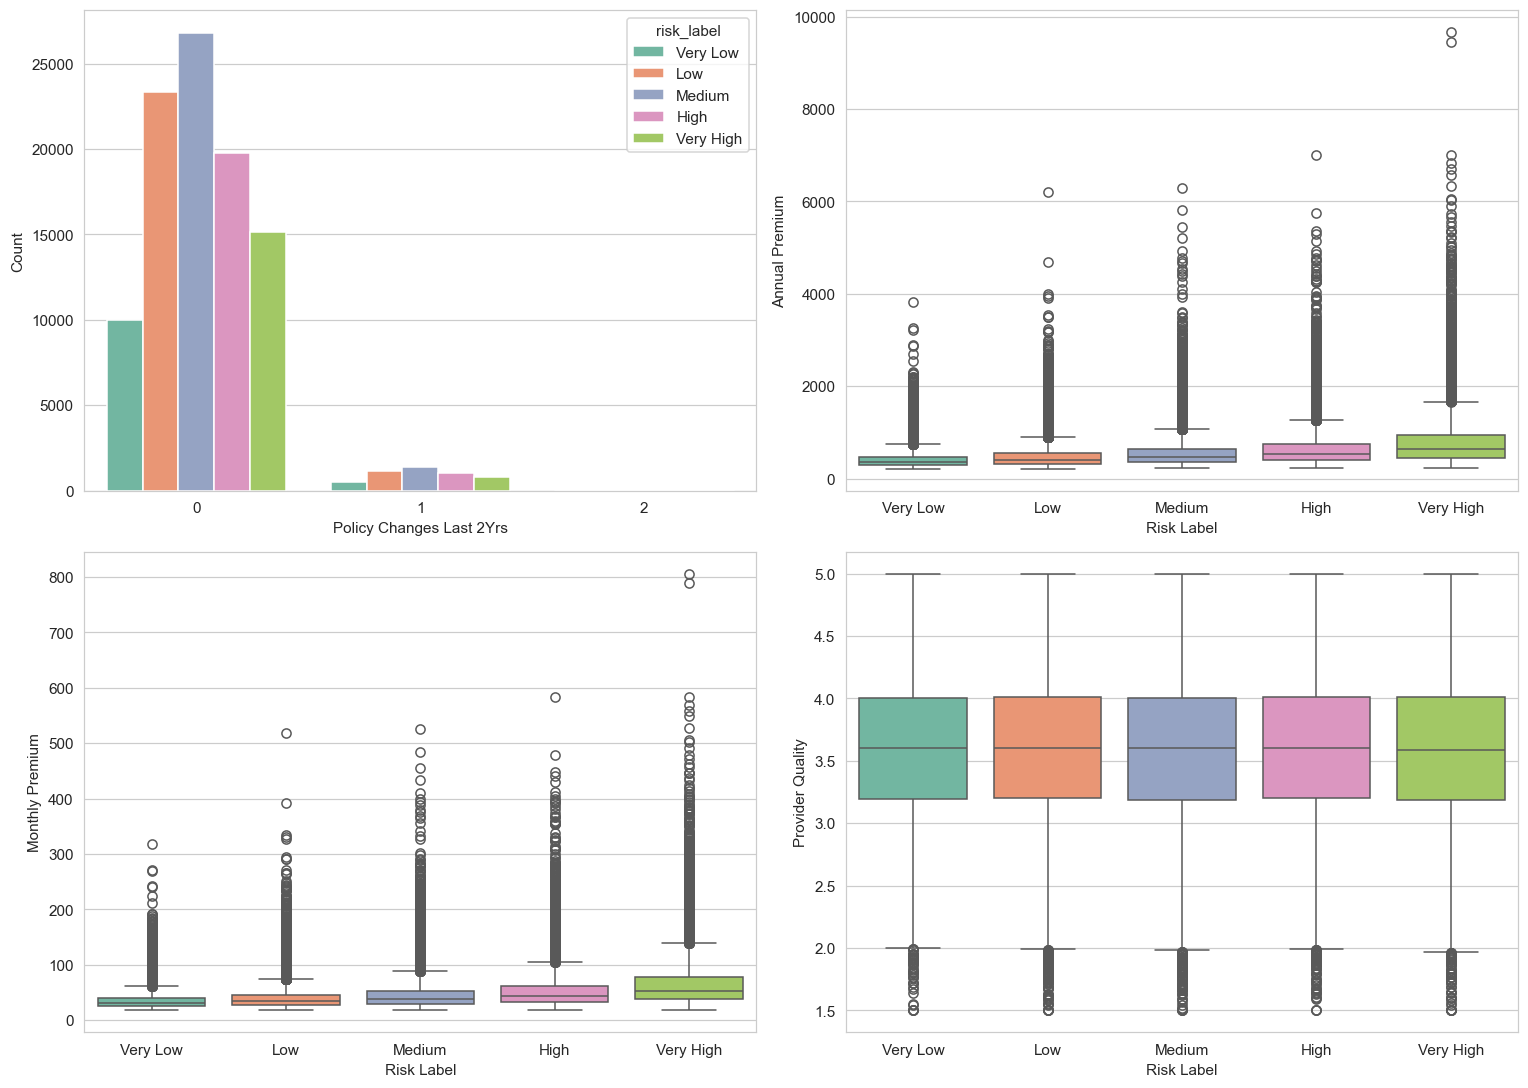

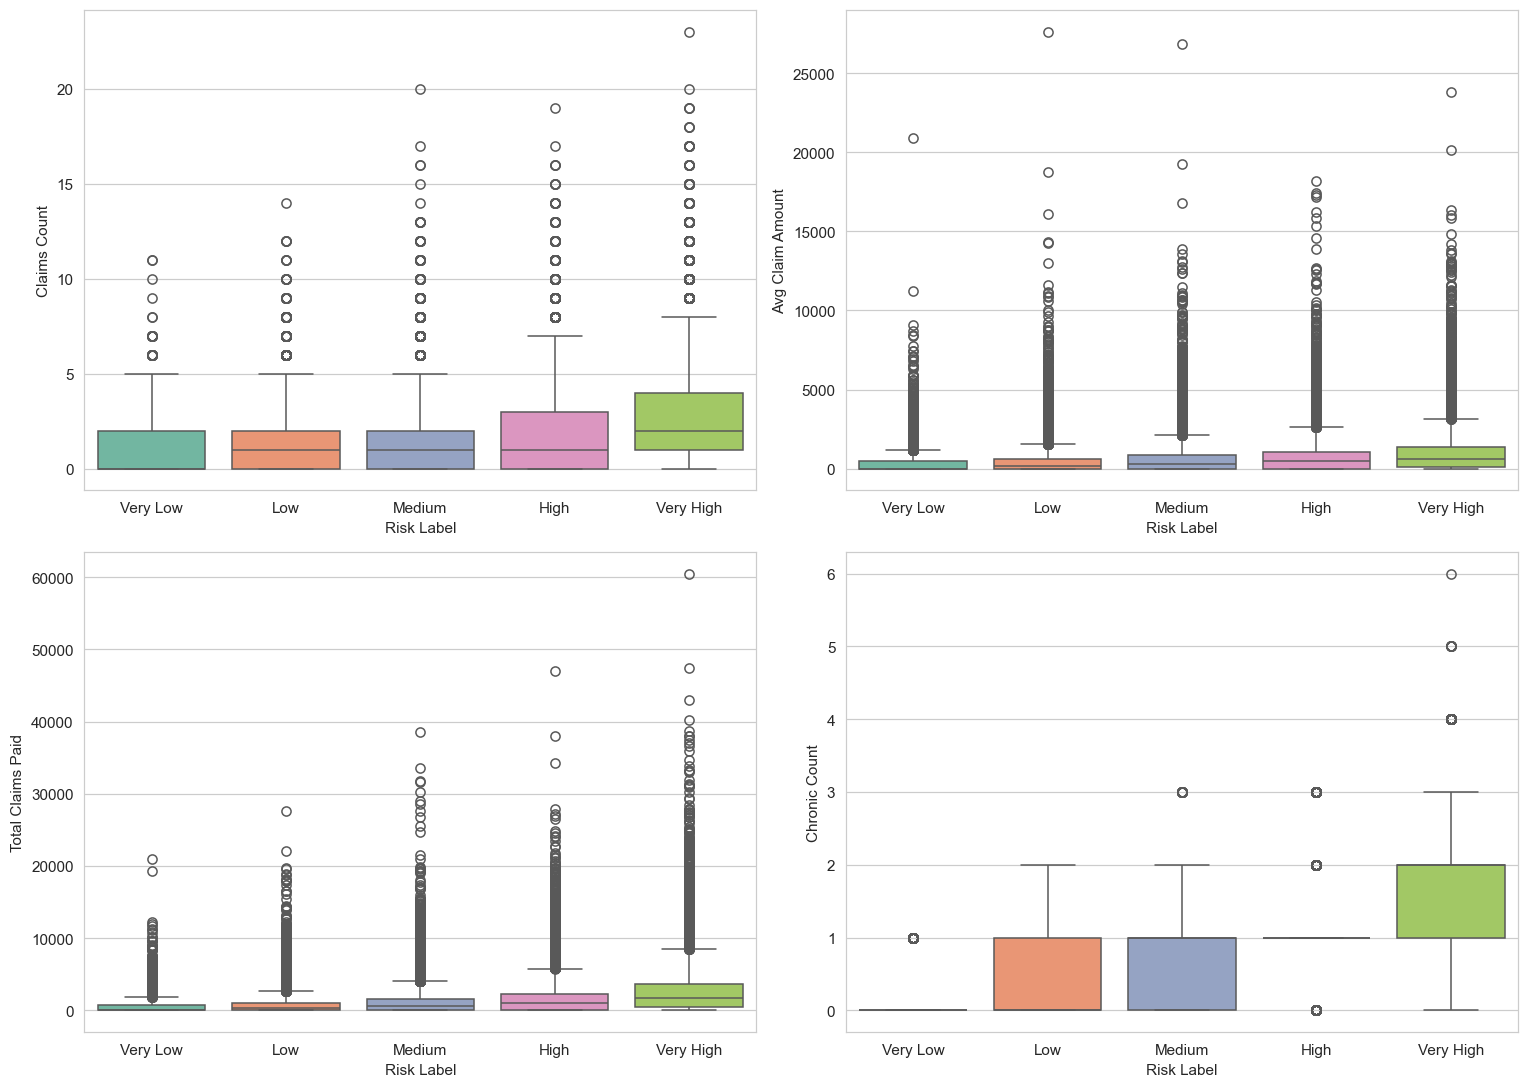

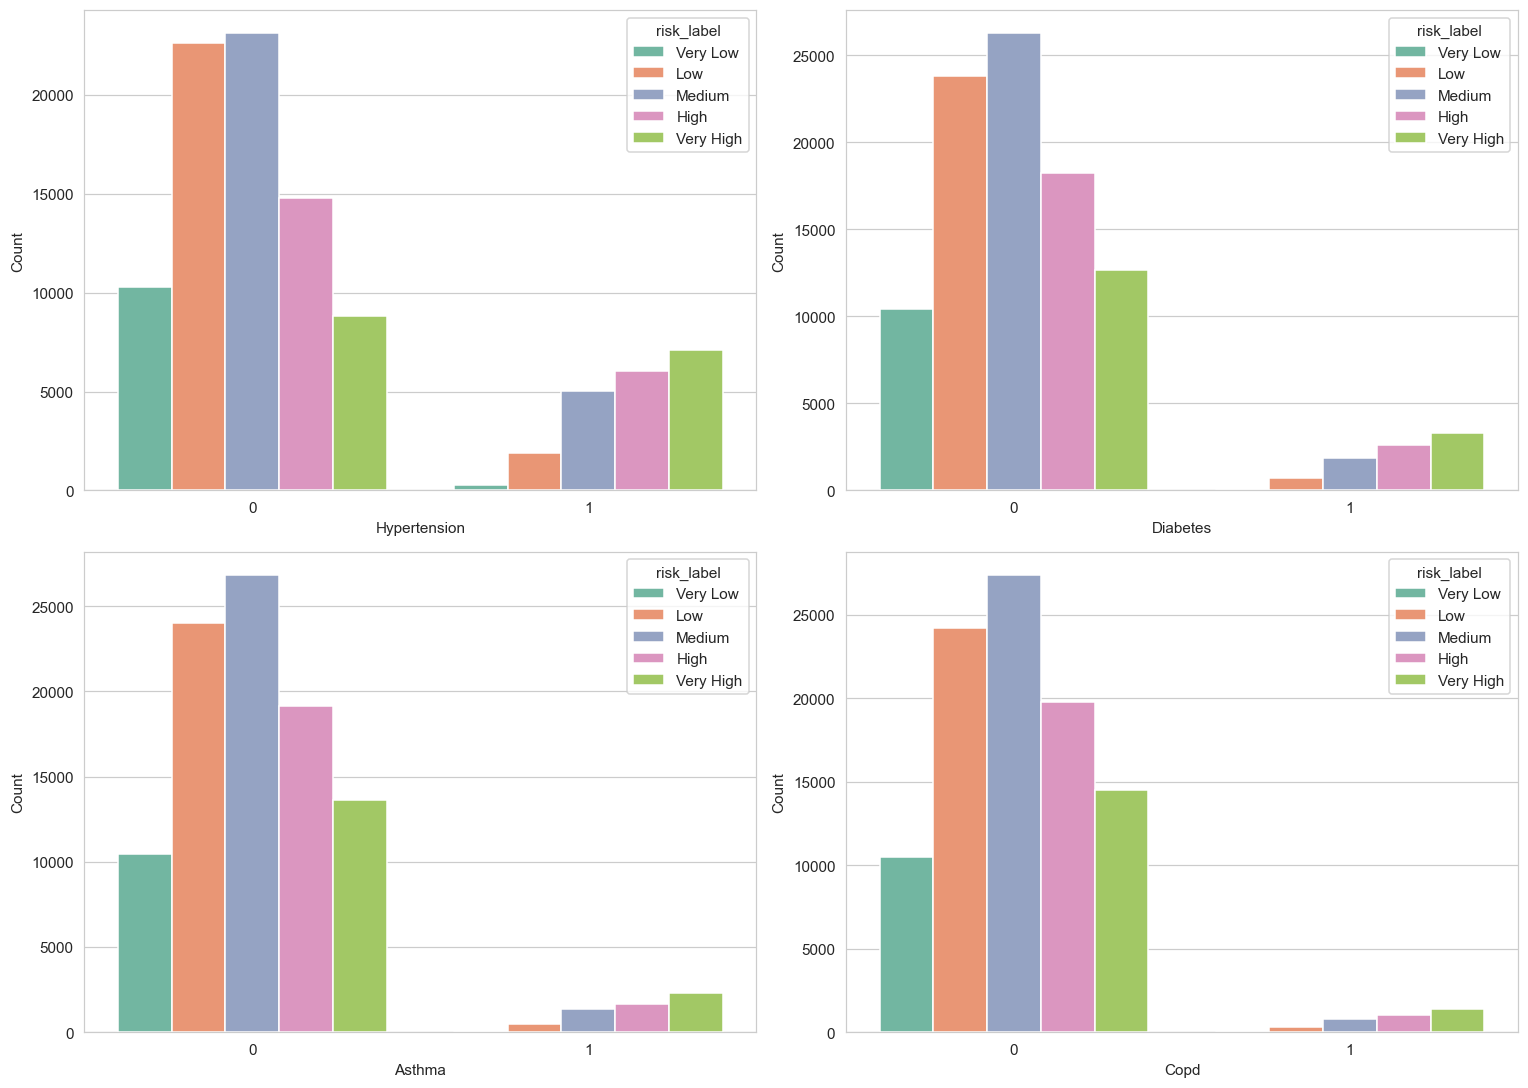

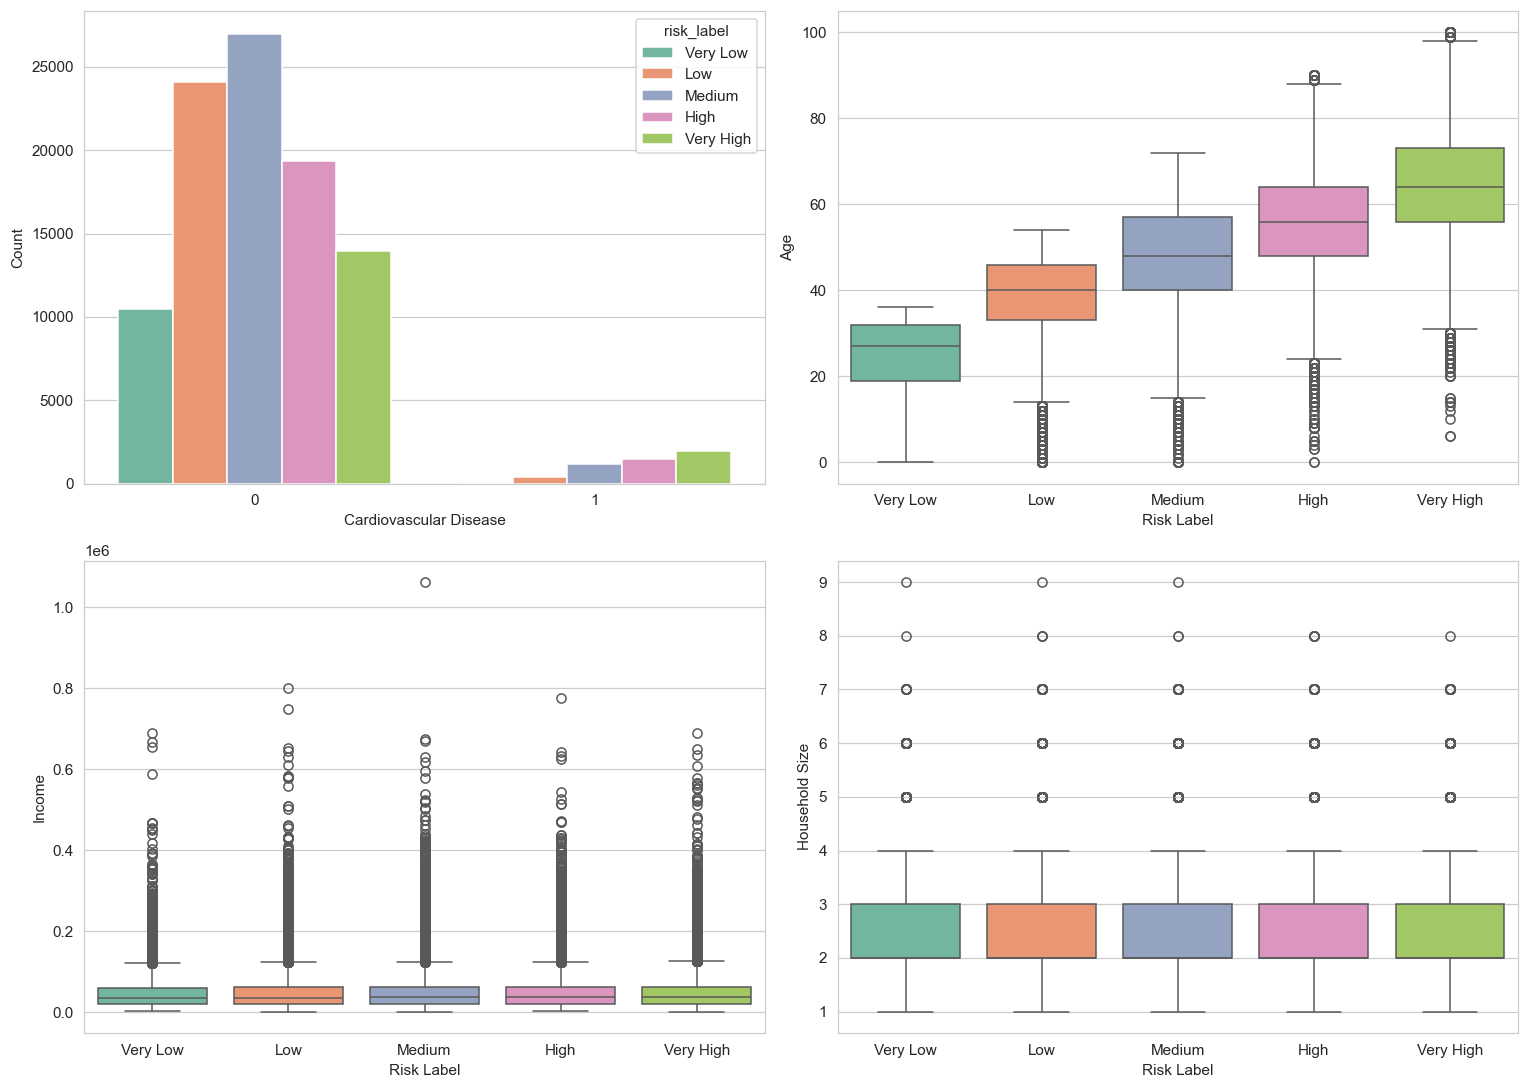

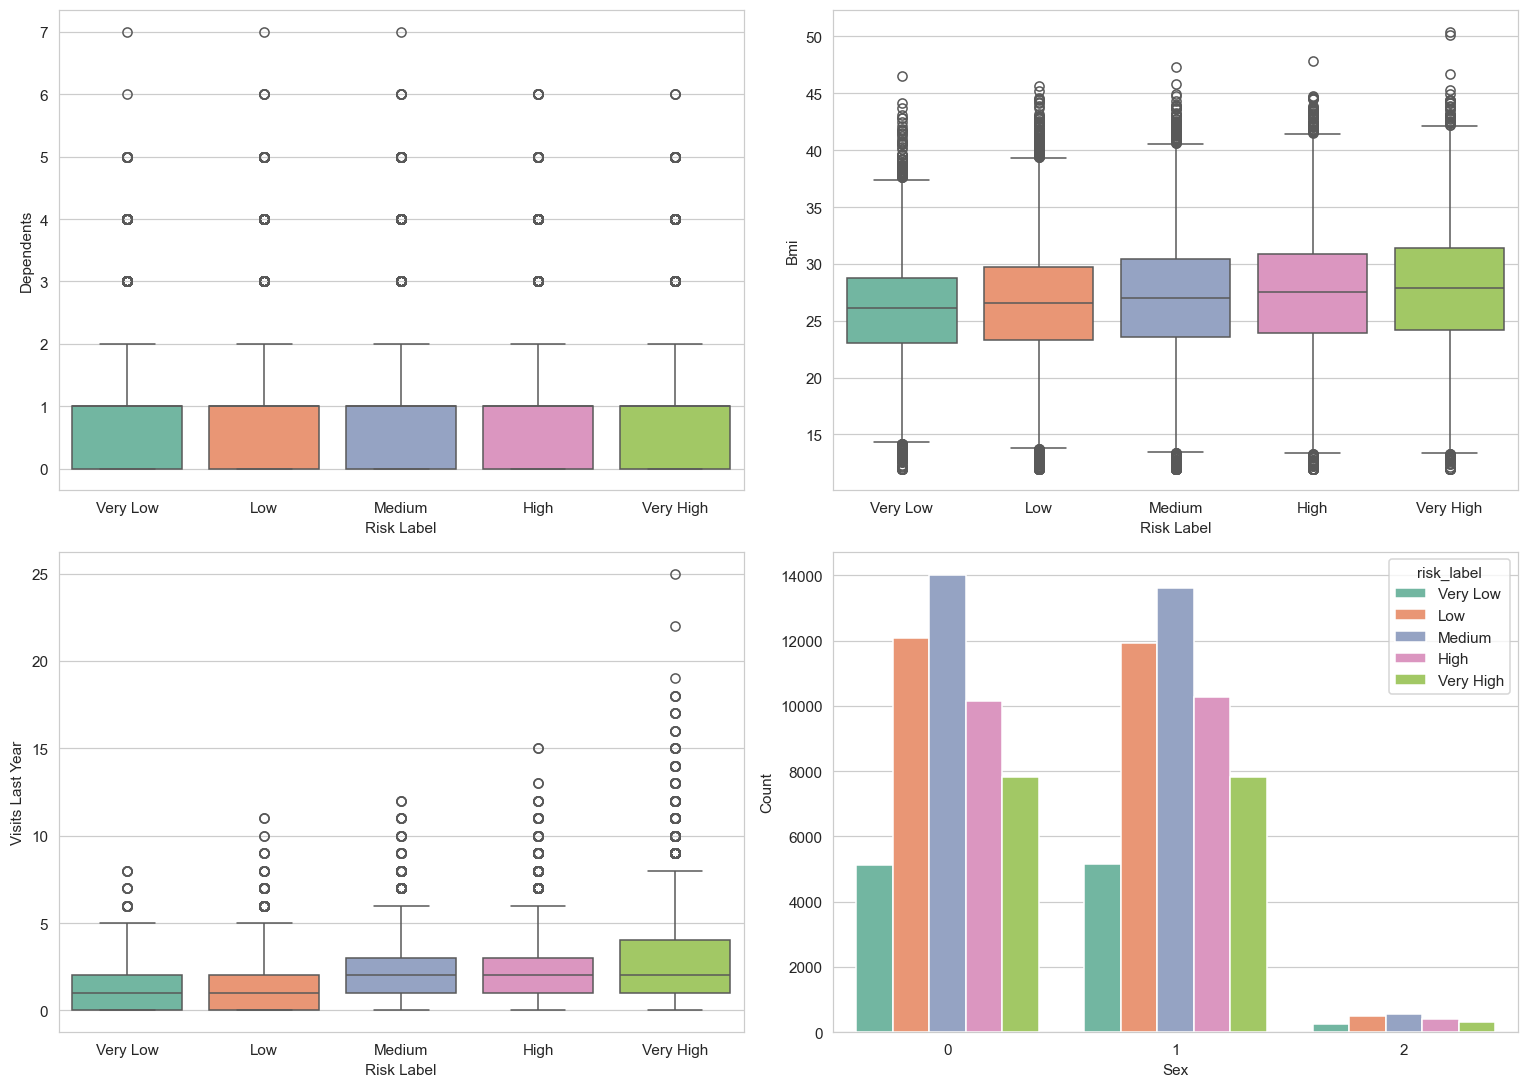

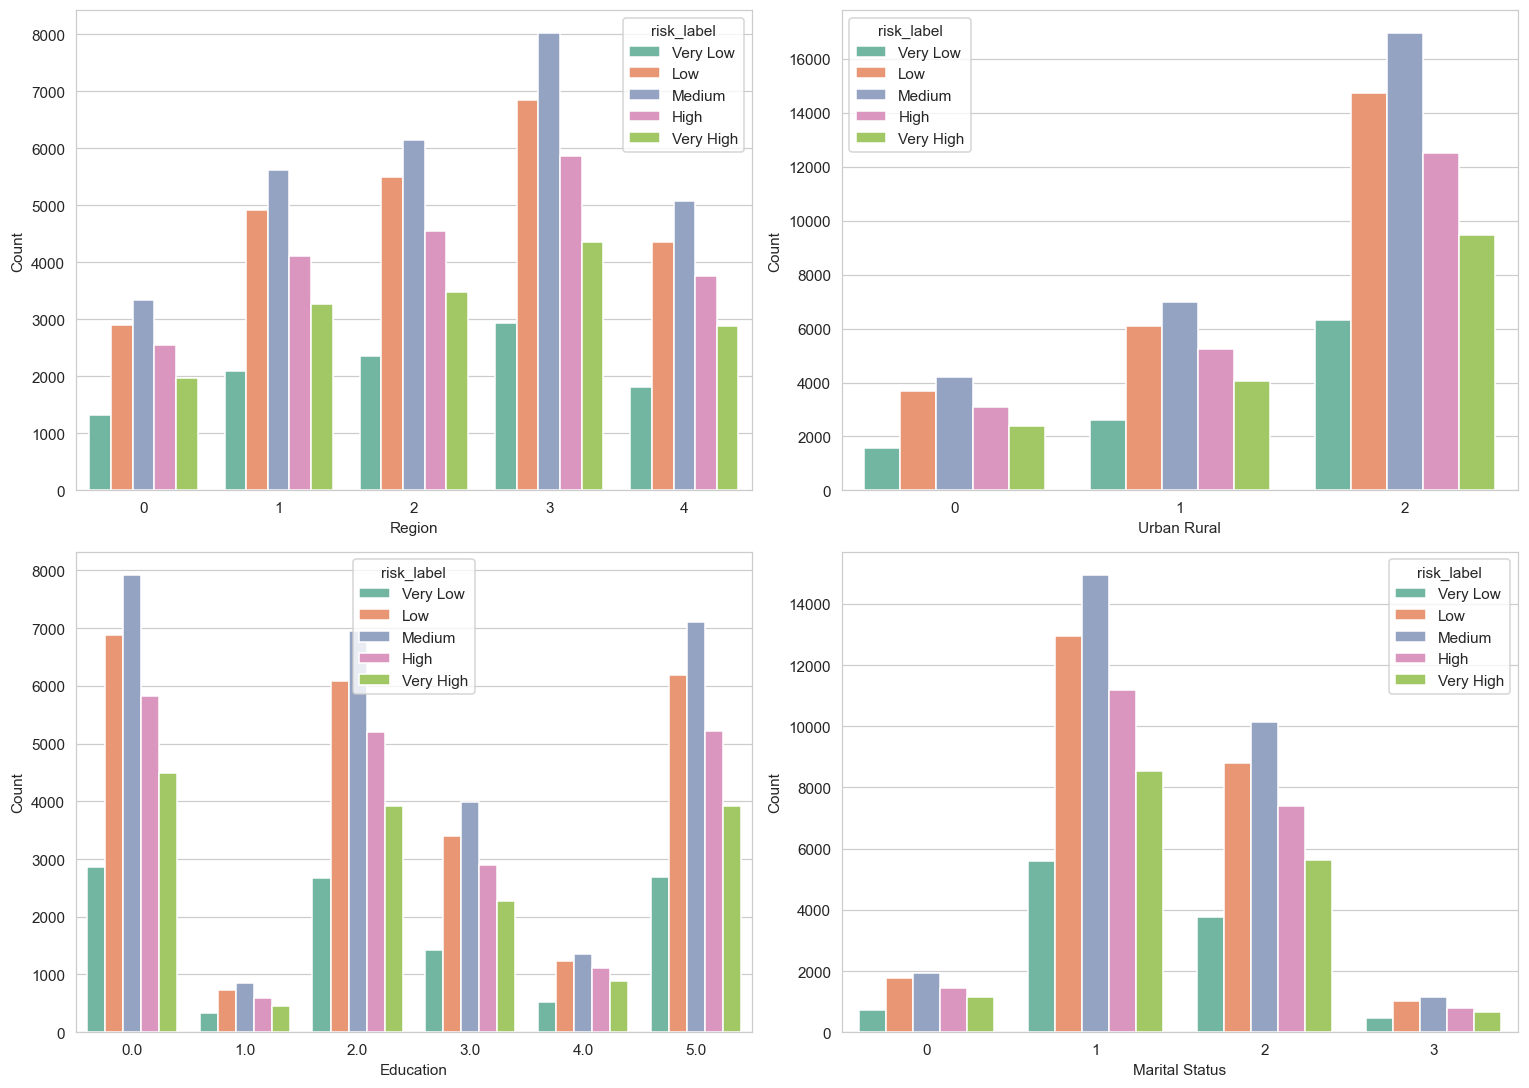

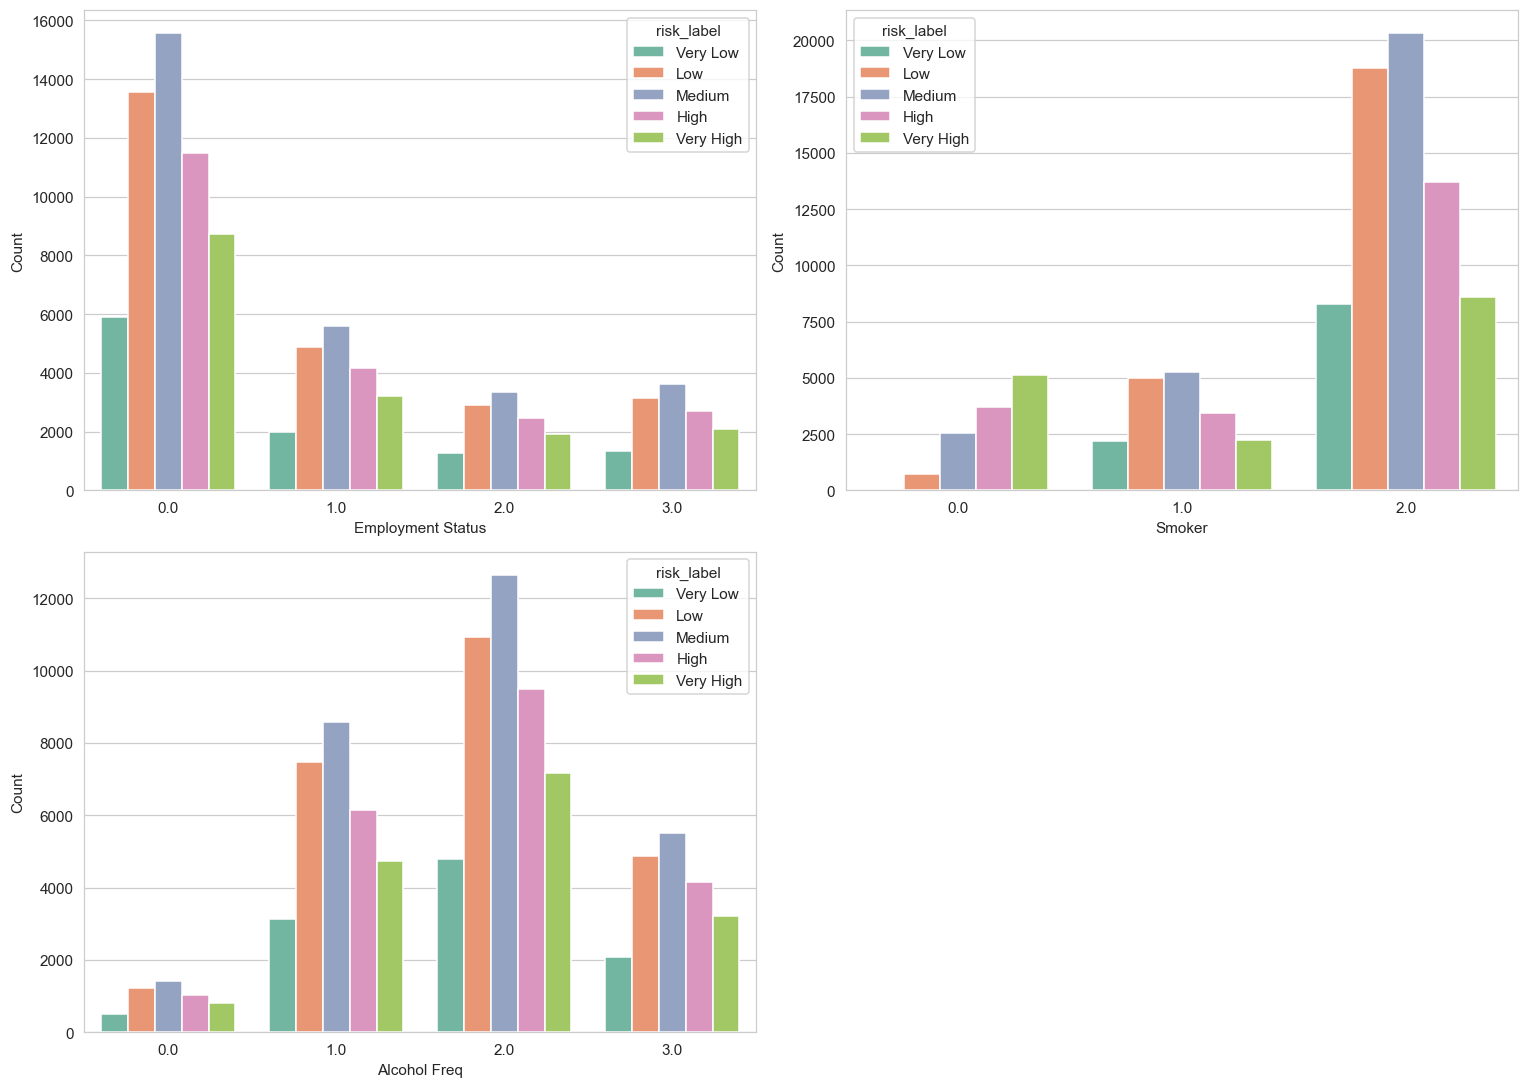

In [6]:
# ---------------------------
# Encoding (hybrid deterministic)
# ---------------------------
df_enc = df[[RISK_LABEL_NAME] + candidate_features].copy()
encoded_parts = []
for col in df_enc.columns:
    if col == RISK_LABEL_NAME or np.issubdtype(df_enc[col].dtype, np.number):
        encoded_parts.append(df_enc[[col]])
    else:
        encoded_parts.append(smart_encode_column(df_enc[col]))
df_enc = pd.concat(encoded_parts, axis=1)
print("\nEncoding complete. Encoded columns:", df_enc.shape[1])

# Quick plotting
batch_size = 4
for i in range(0, len(candidate_features), batch_size):
    plot_classification_features(df_enc, candidate_features[i:i+batch_size])


In [7]:
# ---------------------------
# Robust ordinal mapping + numeric-only correlation
# ---------------------------
label_ord_map = {lab: idx for idx, lab in enumerate(RISK_BIN_LABELS)}
df_enc['_risk_ord'] = df_enc[RISK_LABEL_NAME].map(label_ord_map).astype(float)

numeric_features = df_enc.select_dtypes(include=[np.number]).columns.tolist()
if '_risk_ord' in numeric_features:
    numeric_features.remove('_risk_ord')

numeric_df = df_enc[numeric_features].loc[:, df_enc[numeric_features].nunique() > 1].dropna(axis=1, how='all')
y_corr = df_enc['_risk_ord']

# correlation with target
corr_scores = numeric_df.apply(lambda col: abs(col.corr(y_corr)))

# f-score using SelectKBest
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns, index=numeric_df.index)
skb = SelectKBest(score_func=f_classif, k='all')
skb.fit(X_scaled, y_corr)
f_scores = pd.Series(skb.scores_, index=numeric_df.columns)

# Combine ratings
feature_ratings = pd.DataFrame({
    'Feature': numeric_df.columns,
    'Abs_Corr': corr_scores.values,
    'F_Score': f_scores.values
})
feature_ratings['Decision'] = feature_ratings.apply(
    lambda row: 'Keep' if (row['Abs_Corr'] >= 0.1 and row['F_Score'] >= 0.1) else 'Drop', axis=1
)

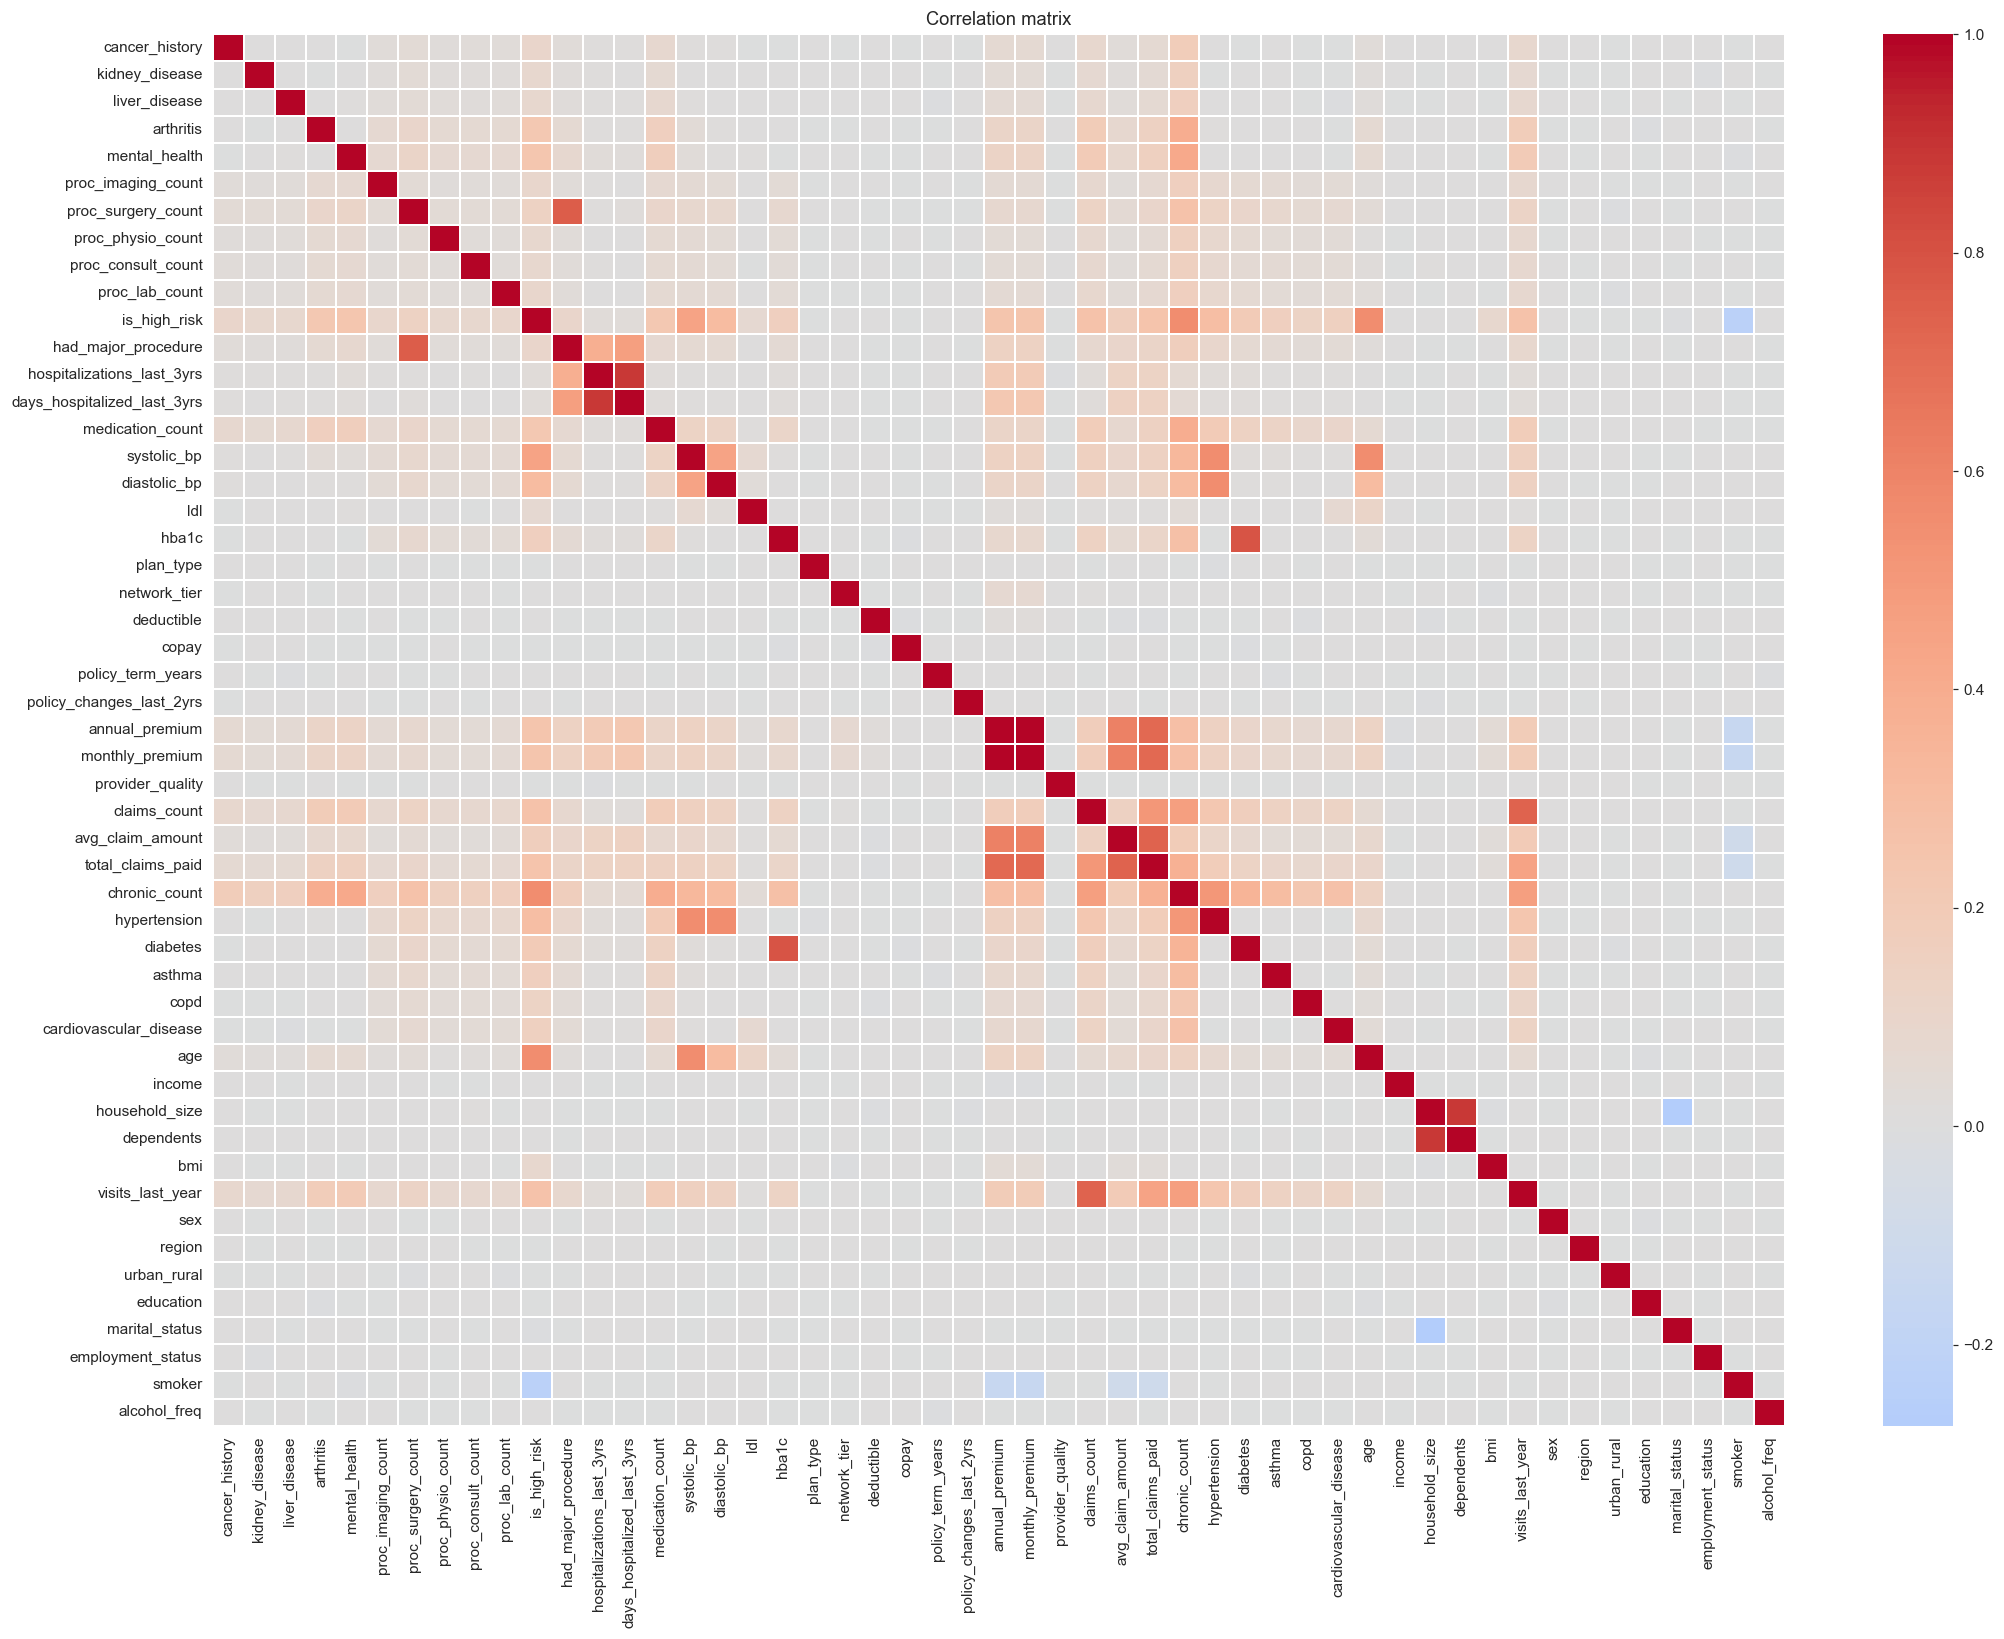

In [8]:
# Full correlation heatmap
if SHOW_PLOTS:
    plt.figure(figsize=(20,15))
    sns.heatmap(df_enc[numeric_features].corr(), cmap='coolwarm', center=0, annot=False, linewidths=0.3)
    plt.title("Correlation matrix")
    plt.tight_layout(); plt.show()

In [9]:
# ---------------------------
# Remove leakage features before RF importances
# ---------------------------
numeric_df_safe = numeric_df.drop(columns=['risk_score','is_high_risk'], errors='ignore')
X_scaled_safe = scaler.fit_transform(numeric_df_safe)

print(f"\nDropping 'risk_score' and 'is_high_risk' from numeric features")



Dropping 'risk_score' and 'is_high_risk' from numeric features



RandomForest importances (top 15):
          Feature  Importance
              age    0.371282
    chronic_count    0.152302
           smoker    0.064562
              bmi    0.054625
      systolic_bp    0.046129
     diastolic_bp    0.018713
            hba1c    0.016887
   annual_premium    0.016672
  monthly_premium    0.016137
     hypertension    0.014658
total_claims_paid    0.014610
    mental_health    0.014204
              ldl    0.013985
           income    0.013302
 provider_quality    0.012991




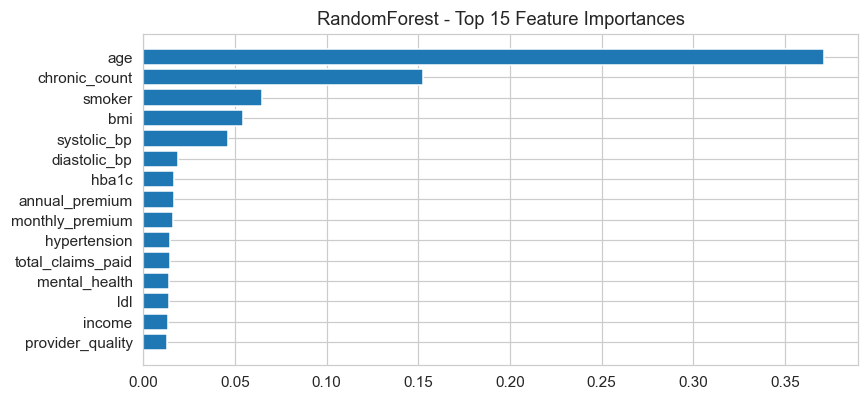

In [10]:
# RandomForest importances
rf_clf = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_scaled_safe, y_corr)
rf_importances = pd.DataFrame({'Feature': numeric_df_safe.columns, 'Importance': rf_clf.feature_importances_})
rf_importances = rf_importances.sort_values('Importance', ascending=False)
print("\nRandomForest importances (top 15):")
print(rf_importances.head(15).to_string(index=False))
print("\n")

if SHOW_PLOTS:
    plt.figure(figsize=(8, max(3, 0.25 * min(15, len(rf_importances)))))
    topn = rf_importances.head(15)
    plt.barh(topn['Feature'][::-1], topn['Importance'][::-1])
    plt.title("RandomForest - Top 15 Feature Importances")
    plt.tight_layout(); plt.show()


In [11]:
# ---------------------------
# Keep only selected features after rating and drop leakage
# ---------------------------
keep_features = [f for f in feature_ratings[feature_ratings['Decision']=='Keep']['Feature'] 
                 if f not in ['risk_score','is_high_risk']]
dropped_features = [f for f in feature_ratings['Feature'] if f not in keep_features]

print(f"\nSelected features before multicollinearity check: {len(keep_features)} / {len(feature_ratings)}")
print("Dropped features:", ', '.join(dropped_features))

# ---------------------------
# Remove multicollinear features (threshold = 0.8)
# ---------------------------
corr_matrix = df[keep_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
keep_features = [f for f in keep_features if f not in to_drop]

print(f"\nSelected features after removing multicollinear features: {len(keep_features)}")
print("Dropped due to multicollinearity:", ', '.join(to_drop))


Selected features before multicollinearity check: 26 / 51
Dropped features: kidney_disease, liver_disease, proc_physio_count, proc_consult_count, is_high_risk, hospitalizations_last_3yrs, days_hospitalized_last_3yrs, ldl, plan_type, network_tier, deductible, copay, policy_term_years, policy_changes_last_2yrs, provider_quality, income, household_size, dependents, sex, region, urban_rural, education, marital_status, employment_status, alcohol_freq

Selected features after removing multicollinear features: 25
Dropped due to multicollinearity: monthly_premium


## Step-4- Training Model Analysis

In [12]:
# ---------------------------
# Prepare modeling dataset
# ---------------------------
df_model = df_enc[[RISK_LABEL_NAME]+keep_features].dropna()
X = df_model[keep_features].copy()
y = df_model[RISK_LABEL_NAME].astype(str).copy()
print(f"Modeling dataset: {X.shape[0]} samples, {X.shape[1]} features")

# Train/test split + scaling
X = X.fillna(X.mean())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'RidgeClassifier': RidgeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(n_estimators=150, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=150, random_state=RANDOM_STATE, eval_metric='mlogloss')
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=500, max_depth=7, learning_rate=0.05, num_leaves=50, min_child_samples=20, subsample=0.8, colsample_bytree=0.8, class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)

Modeling dataset: 99990 samples, 25 features


In [13]:
# Map risk labels to integers for XGBoost
risk_label_map = {lab: idx for idx, lab in enumerate(RISK_BIN_LABELS)}
y_train_xgb = y_train.map(risk_label_map)
y_test_xgb  = y_test.map(risk_label_map)

In [14]:
# ---------------------------
# Train loop
# ---------------------------
results = []
trained = {}
models_trained = {}
label_binarizer = LabelBinarizer()
label_binarizer.fit(y)

for name, model in models.items():
    print(f"\nTraining {name}...")
    t0 = time.time()
    
    # Select proper data
    if name in ['LogisticRegression', 'KNN']:
        Xtr, Xte = X_train_scaled, X_test_scaled
        ytr, yte = y_train, y_test
    elif name == 'XGBoost':
        Xtr, Xte = X_train, X_test
        ytr, yte = y_train_xgb, y_test_xgb
    else:
        Xtr, Xte = X_train, X_test
        ytr, yte = y_train, y_test

    # Train
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    y_proba = None
    try:
        y_proba = model.predict_proba(Xte)
    except Exception:
        y_proba = None
        
    # Metrics
    acc = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average='macro', zero_division=0)
    rec = recall_score(yte, y_pred, average='macro', zero_division=0)
    f1 = f1_score(yte, y_pred, average='macro', zero_division=0)
    # ROC-AUC only if more than 1 class
    roc_auc_ovr = None
    if y_proba is not None:
        yte_bin = label_binarizer.transform(yte)
        if yte_bin.shape[1] > 1:
            if yte_bin.shape[1] != y_proba.shape[1]:
                y_proba_df = pd.DataFrame(y_proba, columns=model.classes_)
                y_proba = y_proba_df[label_binarizer.classes_].values
            roc_auc_ovr = roc_auc_score(yte_bin, y_proba, multi_class='ovr')
    elapsed = time.time() - t0
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC_ovr': roc_auc_ovr,
        'Time_s': elapsed
    })
    trained[name] = (model, y_proba)
    models_trained[name] = model

    print(f" -> acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f} roc_auc_ovr={roc_auc_ovr}")
    print(classification_report(yte, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print("\nClassification summary:")
print(results_df.to_string(index=False))


Training LogisticRegression...
 -> acc=0.8136 prec=0.8269 rec=0.8191 f1=0.8228 roc_auc_ovr=0.9696905503223541
              precision    recall  f1-score   support

        High       0.76      0.77      0.77      4166
         Low       0.81      0.83      0.82      4904
      Medium       0.78      0.79      0.79      5636
   Very High       0.89      0.87      0.88      3189
    Very Low       0.88      0.84      0.86      2103

    accuracy                           0.81     19998
   macro avg       0.83      0.82      0.82     19998
weighted avg       0.81      0.81      0.81     19998


Training RidgeClassifier...
 -> acc=0.5774 prec=0.4950 rec=0.5239 f1=0.4446 roc_auc_ovr=None
              precision    recall  f1-score   support

        High       0.74      0.13      0.22      4166
         Low       0.54      0.94      0.69      4904
      Medium       0.65      0.59      0.62      5636
   Very High       0.55      0.96      0.70      3189
    Very Low       0.00      0.00  

In [15]:
# ---------------------------
# Cross-validation
# ---------------------------
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

print("\n=== Cross-validation (F1-macro) ===")

for name, model in models.items():
    # Select proper data
    if name in ['LogisticRegression', 'KNN']:
        X_use, y_use = X_train_scaled, y_train
    elif name == 'XGBoost':
        X_use, y_use = X_train, y_train_xgb
    else:
        X_use, y_use = X_train, y_train

    try:
        scores = cross_val_score(model, X_use, y_use, cv=skf, scoring='f1_macro', n_jobs=-1)
        cv_results.append({
            'Model': name,
            'CV_F1_Mean': scores.mean(),
            'CV_F1_Std': scores.std()
        })
        print(f"{name}: CV F1-macro = {scores.mean():.4f} ± {scores.std():.4f}")
    except Exception as e:
        print(f"❌ CV failed for {name}: {e}")

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_F1_Mean', ascending=False).reset_index(drop=True)
print("\nCross-validation summary:")
print(cv_results_df.to_string(index=False))


=== Cross-validation (F1-macro) ===
LogisticRegression: CV F1-macro = 0.8219 ± 0.0024
RidgeClassifier: CV F1-macro = 0.4445 ± 0.0028
RandomForest: CV F1-macro = 0.9967 ± 0.0002
GradientBoosting: CV F1-macro = 0.9988 ± 0.0002
AdaBoost: CV F1-macro = 0.3827 ± 0.0425
DecisionTree: CV F1-macro = 0.9999 ± 0.0001
KNN: CV F1-macro = 0.7277 ± 0.0025
XGBoost: CV F1-macro = 1.0000 ± 0.0000
LightGBM: CV F1-macro = 1.0000 ± 0.0000

Cross-validation summary:
             Model  CV_F1_Mean  CV_F1_Std
           XGBoost    0.999955   0.000041
          LightGBM    0.999951   0.000042
      DecisionTree    0.999862   0.000146
  GradientBoosting    0.998806   0.000151
      RandomForest    0.996707   0.000223
LogisticRegression    0.821942   0.002355
               KNN    0.727714   0.002516
   RidgeClassifier    0.444457   0.002765
          AdaBoost    0.382748   0.042462



Best model: LightGBM


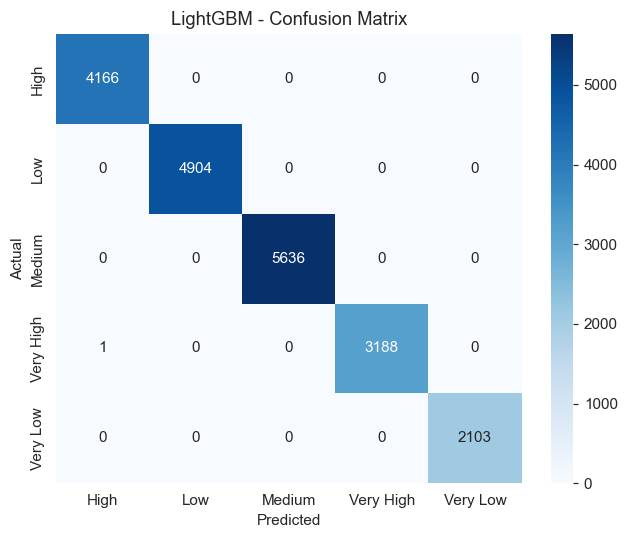

In [16]:
# Diagnostics for best model
best_name = results_df.iloc[0]['Model']
best_model, best_proba = trained[best_name]
print(f"\nBest model: {best_name}")

Xte_use = X_test_scaled if best_name in ['LogisticRegression','KNN'] else X_test
y_pred_best = best_model.predict(Xte_use)
cm = confusion_matrix(y_test, y_pred_best, labels=label_binarizer.classes_)

if SHOW_PLOTS:
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_binarizer.classes_, yticklabels=label_binarizer.classes_)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'{best_name} - Confusion Matrix')
    plt.tight_layout(); plt.show()


LightGBM - Top 15 Feature Importances:
          Feature  Importance
              age       27363
    chronic_count       11419
      systolic_bp        9018
              bmi        8999
           smoker        6627
     diastolic_bp        3493
     hypertension        2770
   annual_premium        2447
            hba1c        2178
  monthly_premium        1824
total_claims_paid        1646
    mental_health        1617
        arthritis        1300
 avg_claim_amount        1104
 visits_last_year        1056




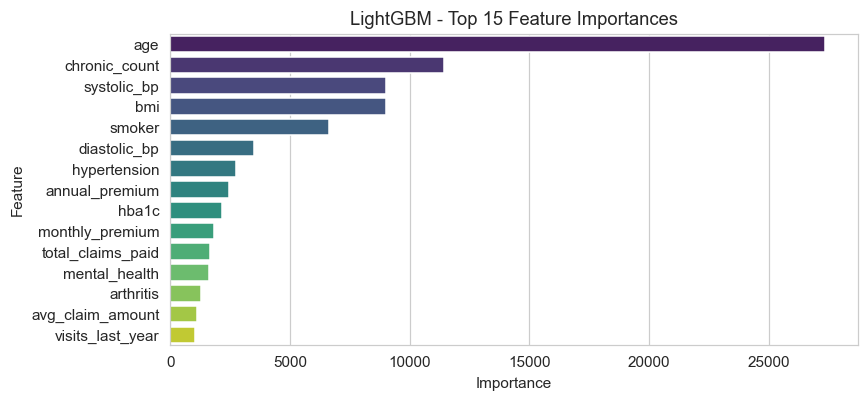

In [17]:
# ---------------------------
# Feature importances for best model
# ---------------------------
def plot_best_model_importances(model, feature_names, top_n=15, show=SHOW_PLOTS):
    importances = None

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # for linear models (multiclass)
        if model.coef_.ndim == 2:  
            importances = np.mean(np.abs(model.coef_), axis=0)
        else:
            importances = np.abs(model.coef_)
    else:
        print(f"⚠️ {best_name} does not support feature importances.")
        return

    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

    print(f"\n{best_name} - Top {top_n} Feature Importances:")
    print(feat_imp_df.head(top_n).to_string(index=False))
    print("\n")

    if show:
        plt.figure(figsize=(8, max(3, 0.25 * min(top_n, len(feat_imp_df)))))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(top_n), palette='viridis')
        plt.title(f'{best_name} - Top {top_n} Feature Importances')
        plt.tight_layout()
        plt.show()

# Call the plotting function
plot_best_model_importances(best_model, keep_features, top_n=15)

### Step-5- Best Model Analysis

In [17]:
best_model = models_trained[best_name]

In [18]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

In [20]:
def evaluate_classification_performance(y_train, y_pred_train, y_test, y_pred_test):
    """
    Comprehensive evaluation of classification performance and overfitting/underfitting detection
    """
    
    print("=" * 60)
    print(f"COMPREHENSIVE PERFORMANCE EVALUATION:")
    print("=" * 60)
    
    # Calculate metrics for both sets
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    train_precision = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)
    test_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    
    train_recall = recall_score(y_train, y_pred_train, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
    
    train_f1 = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    
    # Create comparison table
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Train': [train_accuracy, train_precision, train_recall, train_f1],
        'Test': [test_accuracy, test_precision, test_recall, test_f1],
        'Difference': [
            train_accuracy - test_accuracy,
            train_precision - test_precision,
            train_recall - test_recall,
            train_f1 - test_f1
        ]
    })
    
    print("\n📊 PERFORMANCE METRICS COMPARISON:")
    print(metrics_df.round(4))
    
    # Overfitting/Underfitting Analysis
    print(f"\n🔍 OVERFITTING/UNDERFITTING ANALYSIS:")
    accuracy_gap = train_accuracy - test_accuracy
    
    if accuracy_gap > 0.1:
        print("🚨 STRONG OVERFITTING DETECTED: Large gap between train and test performance")
    elif accuracy_gap > 0.05:
        print("⚠️  MODERATE OVERFITTING DETECTED: Noticeable gap between train and test performance")
    elif accuracy_gap < -0.05:
        print("⚠️  POSSIBLE UNDERFITTING: Model performs poorly on both sets")
    else:
        print("✅ GOOD GENERALIZATION: Similar performance on train and test sets")
    
    print(f"   Accuracy Gap: {accuracy_gap:.4f}")
    
    # Detailed classification reports
    print(f"\n📋 DETAILED CLASSIFICATION REPORT - TRAINING SET:")
    print(classification_report(y_train, y_pred_train))
    
    print(f"\n📋 DETAILED CLASSIFICATION REPORT - TEST SET:")
    print(classification_report(y_test, y_pred_test))
    
    return metrics_df

def plot_confusion_matrices(y_train, y_pred_train, y_test, y_pred_test):
    """
    Plot confusion matrices for both training and test sets
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Training set confusion matrix
    cm_train = confusion_matrix(y_train, y_pred_train)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title('Confusion Matrix - Training Set')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    
    # Test set confusion matrix
    cm_test = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title('Confusion Matrix - Test Set')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

def plot_performance_comparison(metrics_df):
    """
    Plot performance comparison between train and test sets with labels above and to the right
    """
    plt.figure(figsize=(10, 6))
    
    metrics = metrics_df['Metric']
    x = range(len(metrics))
    width = 0.35
    
    train_bars = plt.bar([i - width/2 for i in x], metrics_df['Train'], width, label='Train', alpha=0.7, color='blue')
    test_bars = plt.bar([i + width/2 for i in x], metrics_df['Test'], width, label='Test', alpha=0.7, color='red')
    
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Model Performance: Training vs Test Sets', pad=20)
    plt.xticks(x, metrics)
    plt.legend()
    
    plt.ylim(0, 1.2)
    
    plt.grid(True, alpha=0.3)
    
    for bar in train_bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', 
                 ha='center', va='bottom', fontsize=10)
    
    for bar in test_bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', 
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

def learning_curve_analysis(best_model, X_train, y_train, X_test, y_test):
    """
    Simple learning curve analysis to check for overfitting/underfitting
    """
    from sklearn.model_selection import learning_curve
    import numpy as np
    
    train_sizes, train_scores, test_scores = learning_curve(
        best_model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title('Learning Curve')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Analyze learning curve pattern
    final_train_score = train_mean[-1]
    final_test_score = test_mean[-1]
    gap = final_train_score - final_test_score
    
    print(f"\n📈 LEARNING CURVE ANALYSIS:")
    print(f"Final Training Score: {final_train_score:.4f}")
    print(f"Final Validation Score: {final_test_score:.4f}")
    print(f"Gap: {gap:.4f}")
    
    if gap > 0.1:
        print("🚨 Learning curve suggests OVERFITTING")
    elif final_test_score < 0.6:
        print("⚠️ Learning curve suggests UNDERFITTING")
    else:
        print("✅ Learning curve suggests GOOD GENERALIZATION")

def comprehensive_evaluation(y_train, y_pred_train, y_test, y_pred_test):
    """
    Run comprehensive evaluation pipeline
    """
    
    # Evaluate performance
    metrics_df = evaluate_classification_performance(y_train, y_pred_train, y_test, y_pred_test)
    
    # Plot confusion matrices
    plot_confusion_matrices(y_train, y_pred_train, y_test, y_pred_test)
    
    # Plot performance comparison
    plot_performance_comparison(metrics_df)

    return metrics_df

def quick_diagnostic(y_train, y_pred_train, y_test, y_pred_test):
    """
    Quick diagnostic for overfitting/underfitting
    """
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    gap = train_acc - test_acc
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Accuracy Gap: {gap:.4f}")
    
    if gap > 0.1:
        print("🚨 STRONG OVERFITTING - Model memorized training data")
    elif gap > 0.05:
        print("⚠️ MODERATE OVERFITTING - Consider regularization")
    elif test_acc < 0.6 and train_acc < 0.6:
        print("⚠️ UNDERFITTING - Model needs more complexity/training")
    elif abs(gap) < 0.02:
        print("✅ EXCELLENT GENERALIZATION")
    else:
        print("✅ GOOD GENERALIZATION")

In [21]:
evaluate_classification_performance(y_train, y_pred_train, y_test, y_pred_test)

COMPREHENSIVE PERFORMANCE EVALUATION:

📊 PERFORMANCE METRICS COMPARISON:
      Metric  Train    Test  Difference
0   Accuracy    1.0  0.9999      0.0001
1  Precision    1.0  1.0000      0.0000
2     Recall    1.0  0.9999      0.0001
3   F1-Score    1.0  0.9999      0.0001

🔍 OVERFITTING/UNDERFITTING ANALYSIS:
✅ GOOD GENERALIZATION: Similar performance on train and test sets
   Accuracy Gap: 0.0001

📋 DETAILED CLASSIFICATION REPORT - TRAINING SET:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     16663
         Low       1.00      1.00      1.00     19619
      Medium       1.00      1.00      1.00     22542
   Very High       1.00      1.00      1.00     12755
    Very Low       1.00      1.00      1.00      8413

    accuracy                           1.00     79992
   macro avg       1.00      1.00      1.00     79992
weighted avg       1.00      1.00      1.00     79992


📋 DETAILED CLASSIFICATION REPORT - TEST SET:
              

,Metric,Train,Test,Difference
0,Accuracy,1.0,0.99995,0.00005
1,Precision,1.0,0.99995,0.00005
2,Recall,1.0,0.99995,0.00005
3,F1-Score,1.0,0.99995,0.00005


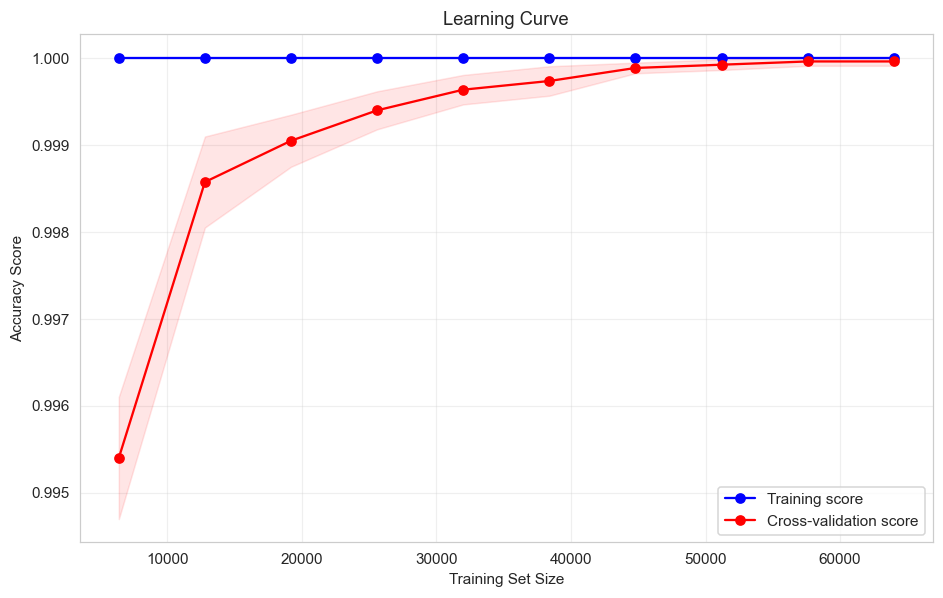


📈 LEARNING CURVE ANALYSIS:
Final Training Score: 1.0000
Final Validation Score: 1.0000
Gap: 0.0000
✅ Learning curve suggests GOOD GENERALIZATION


In [23]:
learning_curve_analysis(best_model, X_train, y_train, X_test, y_test)

COMPREHENSIVE PERFORMANCE EVALUATION:

📊 PERFORMANCE METRICS COMPARISON:
      Metric  Train    Test  Difference
0   Accuracy    1.0  0.9999      0.0001
1  Precision    1.0  1.0000      0.0000
2     Recall    1.0  0.9999      0.0001
3   F1-Score    1.0  0.9999      0.0001

🔍 OVERFITTING/UNDERFITTING ANALYSIS:
✅ GOOD GENERALIZATION: Similar performance on train and test sets
   Accuracy Gap: 0.0001

📋 DETAILED CLASSIFICATION REPORT - TRAINING SET:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     16663
         Low       1.00      1.00      1.00     19619
      Medium       1.00      1.00      1.00     22542
   Very High       1.00      1.00      1.00     12755
    Very Low       1.00      1.00      1.00      8413

    accuracy                           1.00     79992
   macro avg       1.00      1.00      1.00     79992
weighted avg       1.00      1.00      1.00     79992


📋 DETAILED CLASSIFICATION REPORT - TEST SET:
              

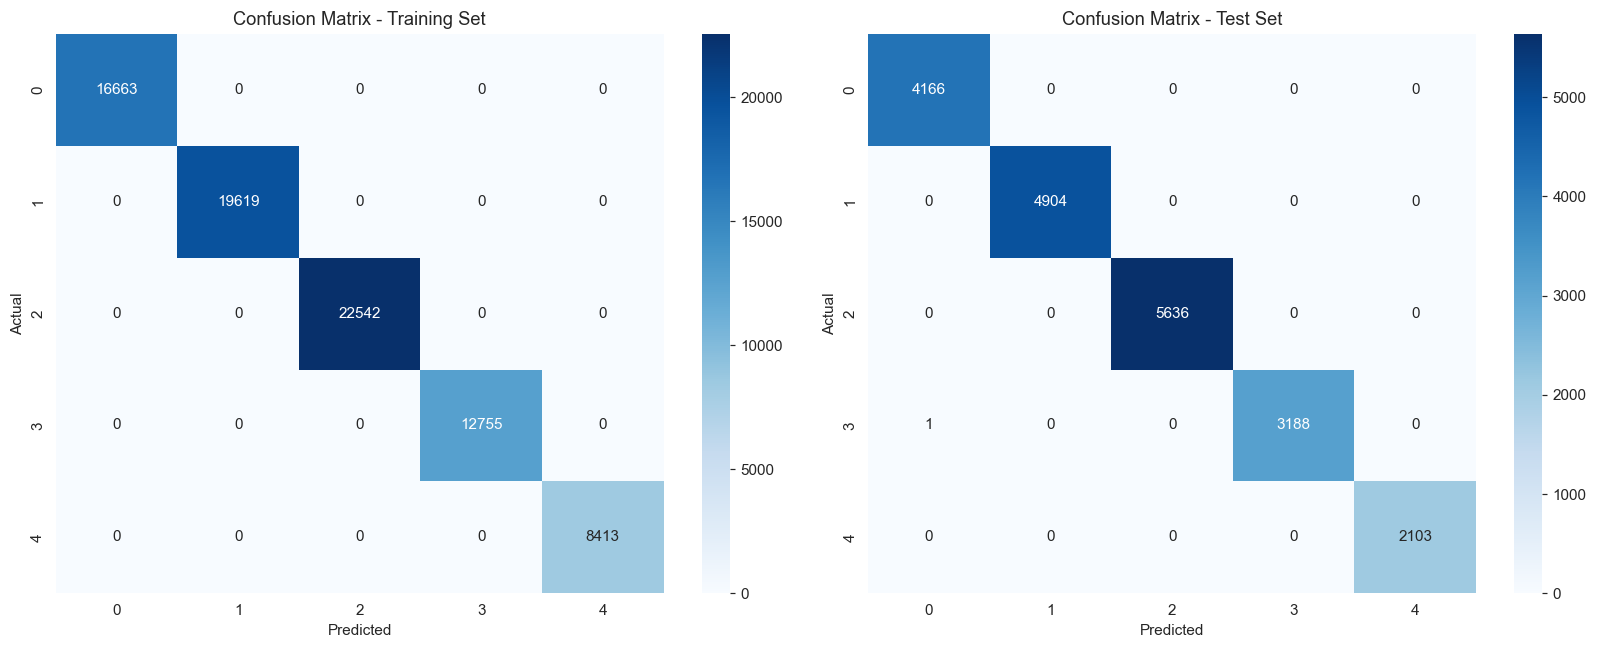

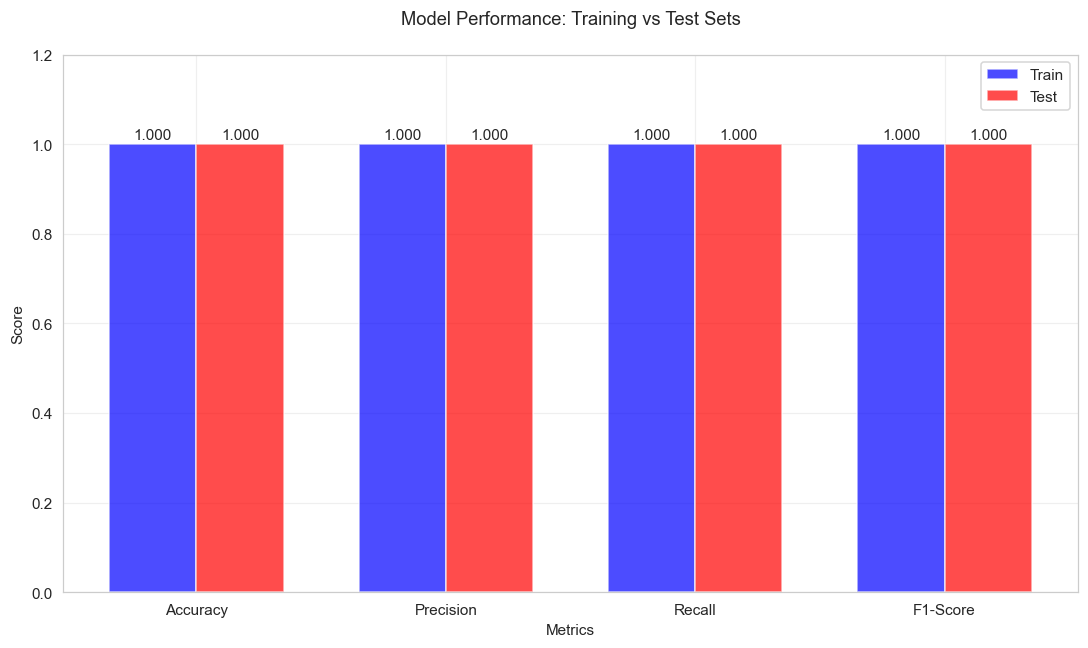

,Metric,Train,Test,Difference
0,Accuracy,1.0,0.99995,0.00005
1,Precision,1.0,0.99995,0.00005
2,Recall,1.0,0.99995,0.00005
3,F1-Score,1.0,0.99995,0.00005


In [24]:
comprehensive_evaluation(y_train, y_pred_train, y_test, y_pred_test)

In [25]:
quick_diagnostic(y_train, y_pred_train, y_test, y_pred_test)

Training Accuracy: 1.0000
Test Accuracy: 0.9999
Accuracy Gap: 0.0001
✅ EXCELLENT GENERALIZATION


### Export Model

In [22]:
joblib.dump(best_model, 'models/risk_score_model.pkl')
joblib.dump(list(X_train.columns), 'features/risk_score_features.pkl')

['risk_score_features.pkl']